In [1]:
import os
import gc

# Set this environment variable BEFORE importing TensorFlow
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

import tensorflow as tf

# Configure GPU memory growth explicitly (may be redundant with env var but harmless)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled by explicit call.")
    except RuntimeError as e:
        print(f"GPU memory growth could not be explicitly set: {e}")
else:
    print("No GPUs found.")

# Clear previous TensorFlow session
tf.keras.backend.clear_session()
gc.collect()

# Now import Keras components, as TF is already configured
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger

# Check TensorFlow version and GPU availability after configuration
print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))
!nvidia-smi # For a comprehensive GPU check

GPU memory growth enabled by explicit call.
TensorFlow version: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Fri Jul 17 20:59:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             45W /  400W |       6MiB /  40960MiB |      0%      Defaul

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
import glob
import zipfile
import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TensorFlow related imports and setup are now handled in the new top cell (cc199d4f).
# Removed redundant 'import tensorflow as tf', '!pip install tensorflow', and related prints from here.
# All tensorflow and keras imports have been moved to cell cc199d4f.


from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    accuracy_score,
    f1_score
)

In [4]:
import os # Import os module here

# ================================
# PATHS
# ================================

ZIP_PATH = "/content/drive/MyDrive/Colab Notebooks/Parkinson_project_using_mobile_net_V2_inclue_F_base_T_F_/Parkinson_dataset.zip"

UNZIP_DIR = "/content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_dataset_unzipped_here"

SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here"

MODEL_DIR = os.path.join(SAVE_DIR, "models")
HISTORY_DIR = os.path.join(SAVE_DIR, "history_files")
GRAPH_DIR = os.path.join(SAVE_DIR, "graphs")
CM_DIR = os.path.join(SAVE_DIR, "confusion_matrices")
REPORT_DIR = os.path.join(SAVE_DIR, "reports")
ROC_DATA_DIR = os.path.join(SAVE_DIR, "ROC_DATA") # Adjusted to be within SAVE_DIR
GRADCAM_DIR = os.path.join(SAVE_DIR, "grad_cam_outputs") # Already consistent with SAVE_DIR

for d in [UNZIP_DIR, SAVE_DIR, MODEL_DIR, HISTORY_DIR, GRAPH_DIR, CM_DIR, REPORT_DIR, ROC_DATA_DIR, GRADCAM_DIR]:
    os.makedirs(d, exist_ok=True)

print("ZIP_PATH:", ZIP_PATH)
print("UNZIP_DIR:", UNZIP_DIR)
print("SAVE_DIR:", SAVE_DIR)
print("ROC_DATA_DIR:", ROC_DATA_DIR)
print("GRADCAM_DIR:", GRADCAM_DIR)

ZIP_PATH: /content/drive/MyDrive/Colab Notebooks/Parkinson_project_using_mobile_net_V2_inclue_F_base_T_F_/Parkinson_dataset.zip
UNZIP_DIR: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_dataset_unzipped_here
SAVE_DIR: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here
ROC_DATA_DIR: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/ROC_DATA
GRADCAM_DIR: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/grad_cam_outputs


In [5]:
print(f"Contents of {UNZIP_DIR}:")
for item in os.listdir(UNZIP_DIR):
    print(os.path.join(UNZIP_DIR, item))

Contents of /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_dataset_unzipped_here:
/content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_dataset_unzipped_here/Parkinson_dataset


In [6]:
parkinson_dataset_path = os.path.join(UNZIP_DIR, 'Parkinson_dataset')
print(f"Contents of {parkinson_dataset_path}:")
if os.path.exists(parkinson_dataset_path):
    for item in os.listdir(parkinson_dataset_path):
        print(os.path.join(parkinson_dataset_path, item))
else:
    print(f"Directory not found: {parkinson_dataset_path}")

Contents of /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_dataset_unzipped_here/Parkinson_dataset:
/content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_dataset_unzipped_here/Parkinson_dataset/healthy_dataset
/content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_dataset_unzipped_here/Parkinson_dataset/parkinson_dataset


In [7]:
# ================================
# UNZIP DATASET
# ================================

if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(f"ZIP file not found: {ZIP_PATH}")

# Define the expected main folder name after unzipping the dataset
# Assuming the zip file will extract into a folder named 'Parkinson_dataset'
expected_extracted_dir = os.path.join(UNZIP_DIR, 'Parkinson_dataset')

# Unzip only if the expected extracted directory does not exist
if not os.path.exists(expected_extracted_dir) or not os.listdir(expected_extracted_dir):
    print(f"Unzipping dataset to {UNZIP_DIR}...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(UNZIP_DIR)
    print("Dataset unzipped to:", UNZIP_DIR)
else:
    print("Dataset already unzipped at:", UNZIP_DIR)


Dataset already unzipped at: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_dataset_unzipped_here


In [8]:
# ================================
# FIND IMAGE FILES
# ================================

image_extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff"]

all_images = []
# Search within the expected extracted directory (e.g., UNZIP_DIR/Parkinson_dataset/)
for ext in image_extensions:
    all_images.extend(glob.glob(os.path.join(expected_extracted_dir, "**", ext), recursive=True))

print("Total images found:", len(all_images))

if len(all_images) == 0:
    raise ValueError("No images found after unzipping. Check your ZIP file structure or the expected_extracted_dir path.")

# Show some image paths
for p in all_images[:10]:
    print(p)


Total images found: 11120
/content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_dataset_unzipped_here/Parkinson_dataset/healthy_dataset/control_png/PPMI_153233_MR_SAG_3D_T1-weighted_br_raw_20230127000630309_27_S1190701_I1660562.png
/content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_dataset_unzipped_here/Parkinson_dataset/healthy_dataset/control_png/PPMI_153233_MR_SAG_3D_T1-weighted_br_raw_20230127000630510_34_S1190701_I1660562.png
/content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_dataset_unzipped_here/Parkinson_dataset/healthy_dataset/control_png/PPMI_153233_MR_SAG_3D_T1-weighted_br_raw_20230127000640905_14_S1190701_I1660562.png
/content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_dataset_unzipped_here/Parkinson_dataset/healthy_dataset/control_png/PPMI_153233_MR_SAG_3D_T1-weighted_br_raw_20230127000657892_154_S1190701_I1660562.png
/content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_dataset_unzipped_here/Parkinson_dataset/healthy_dataset/control_png/PP

In [9]:
# ================================
# CREATE DATAFRAME
# ================================

data = []

for img_path in all_images:
    lower_path = img_path.lower()

    if "healthy" in lower_path or "normal" in lower_path or "control" in lower_path:
        label = 0   # Healthy
        data.append([img_path, label])

    elif "parkinson" in lower_path or "pd" in lower_path:
        label = 1   # Parkinson
        data.append([img_path, label])

df = pd.DataFrame(data, columns=["image_path", "label"])

print("Total labeled images:", len(df))
print(df.head())
print(df["label"].value_counts())

if len(df) == 0:
    raise ValueError("No labeled images found. Folder names must contain healthy/parkinson/normal/control/pd.")

if df["label"].nunique() != 2:
    raise ValueError("Both classes not found. Need Healthy and Parkinson images.")

Total labeled images: 11120
                                          image_path  label
0  /content/drive/MyDrive/Colab Notebooks/Parkins...      0
1  /content/drive/MyDrive/Colab Notebooks/Parkins...      0
2  /content/drive/MyDrive/Colab Notebooks/Parkins...      0
3  /content/drive/MyDrive/Colab Notebooks/Parkins...      0
4  /content/drive/MyDrive/Colab Notebooks/Parkins...      0
label
0    5560
1    5560
Name: count, dtype: int64


In [10]:
print('\nVerifying image counts in subdirectories:')
healthy_path = os.path.join(parkinson_dataset_path, 'healthy_dataset')
parkinson_path = os.path.join(parkinson_dataset_path, 'parkinson_dataset')

healthy_files = []
parkinson_files = []

for ext in image_extensions:
    healthy_files.extend(glob.glob(os.path.join(healthy_path, '**', ext), recursive=True))
    parkinson_files.extend(glob.glob(os.path.join(parkinson_path, '**', ext), recursive=True))

print(f"Files found in 'healthy_dataset': {len(healthy_files)}")
print(f"Files found in 'parkinson_dataset': {len(parkinson_files)}")
print(f"Total files from subdirectories: {len(healthy_files) + len(parkinson_files)}")



Verifying image counts in subdirectories:
Files found in 'healthy_dataset': 5560
Files found in 'parkinson_dataset': 5560
Total files from subdirectories: 11120


In [11]:
# ================================
# SPLIT DATASET
# ================================

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain counts:")
print(train_df["label"].value_counts())

print("\nValidation counts:")
print(val_df["label"].value_counts())

print("\nTest counts:")
print(test_df["label"].value_counts())

Train shape: (7784, 2)
Validation shape: (1668, 2)
Test shape: (1668, 2)

Train counts:
label
1    3892
0    3892
Name: count, dtype: int64

Validation counts:
label
0    834
1    834
Name: count, dtype: int64

Test counts:
label
0    834
1    834
Name: count, dtype: int64


In [12]:
def build_mobilenetv2_model(base_trainable=False):
    base_model = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    base_model.trainable = base_trainable

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = base_model(inputs, training=False)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc")
        ]
    )

    return model

In [13]:
# ================================
# IMAGE GENERATORS
# ================================

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 35

train_df["label"] = train_df["label"].astype(str)
val_df["label"] = val_df["label"].astype(str)
test_df["label"] = test_df["label"].astype(str)

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

val_gen = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Class indices:", train_gen.class_indices)

Found 7784 validated image filenames belonging to 2 classes.
Found 1668 validated image filenames belonging to 2 classes.
Found 1668 validated image filenames belonging to 2 classes.
Class indices: {'0': 0, '1': 1}


In [14]:
# ================================
# BUILD MOBILENETV2 MODEL
# ================================

def build_mobilenetv2_model(base_trainable=False):
    base_model = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    base_model.trainable = base_trainable

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = base_model(inputs, training=False)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc")
        ]
    )

    return model

In [15]:
# ================================
# GRAPH FUNCTION
# ================================

def plot_training_history(history, model_name):
    hist = history.history
    epochs = range(1, len(hist["accuracy"]) + 1)

    # Accuracy graph
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["accuracy"], marker="o", label="Train Accuracy")
    plt.plot(epochs, hist["val_accuracy"], marker="o", label="Validation Accuracy")
    plt.title(f"{model_name} - Accuracy vs Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    acc_path = os.path.join(GRAPH_DIR, f"{model_name}_accuracy_vs_epochs.png")
    plt.savefig(acc_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", acc_path)

    # Loss graph
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["loss"], marker="o", label="Train Loss")
    plt.plot(epochs, hist["val_loss"], marker="o", label="Validation Loss")
    plt.title(f"{model_name} - Loss vs Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    loss_path = os.path.join(GRAPH_DIR, f"{model_name}_loss_vs_epochs.png")
    plt.savefig(loss_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", loss_path)

    # AUC graph
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["auc"], marker="o", label="Train AUC")
    plt.plot(epochs, hist["val_auc"], marker="o", label="Validation AUC")
    plt.title(f"{model_name} - AUC vs Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("AUC")
    plt.legend()
    plt.grid(True)
    auc_path = os.path.join(GRAPH_DIR, f"{model_name}_auc_vs_epochs.png")
    plt.savefig(auc_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", auc_path)

In [16]:
import numpy as np
# ================================
# EVALUATION FUNCTION
# ================================

def evaluate_model(model, test_gen, model_name):
    test_gen.reset()

    y_prob = model.predict(test_gen)
    y_pred = (y_prob > 0.5).astype(int).ravel()
    y_true = test_gen.classes

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    print("\n==============================")
    print(model_name)
    print("==============================")
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print("ROC AUC:", auc)

    report = classification_report(
        y_true,
        y_pred,
        target_names=["Healthy", "Parkinson"]
    )

    print("\nClassification Report:")
    print(report)

    cm = confusion_matrix(y_true, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

    # Save y_true, y_pred, y_prob to a .npz file
    npz_path = os.path.join(CM_DIR, f"{model_name}_predictions.npz")
    np.savez(
        npz_path,
        y_true=y_true,
        y_pred=y_pred,
        y_prob=y_prob
    )
    print("Prediction data (y_true, y_pred, y_prob) saved:", npz_path)

    # Save report
    report_path = os.path.join(REPORT_DIR, f"{model_name}_classification_report.txt")
    with open(report_path, "w") as f:
        f.write(f"Model: {model_name}\n")
        f.write(f"Accuracy: {acc}\n")
        f.write(f"F1 Score: {f1}\n")
        f.write(f"ROC AUC: {auc}\n\n")
        f.write("Classification Report:\n")
        f.write(report)
        f.write("\nConfusion Matrix:\n")
        f.write(str(cm))

    print("Report saved:", report_path)

    # Save confusion matrix CSV
    cm_df = pd.DataFrame(
        cm,
        index=["Actual Healthy", "Actual Parkinson"],
        columns=["Predicted Healthy", "Predicted Parkinson"]
    )

    cm_csv_path = os.path.join(CM_DIR, f"{model_name}_confusion_matrix.csv")
    cm_df.to_csv(cm_csv_path)
    print("Confusion matrix CSV saved:", cm_csv_path)

    # Plot confusion matrix
    plt.figure(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Healthy", "Parkinson"]
    )
    disp.plot(values_format="d")
    plt.title(f"{model_name} - Confusion Matrix")

    cm_png_path = os.path.join(CM_DIR, f"{model_name}_confusion_matrix.png")
    plt.savefig(cm_png_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Confusion matrix image saved:", cm_png_path)

    return {
        "model_name": model_name,
        "accuracy": acc,
        "f1_score": f1,
        "roc_auc": auc
    }

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,481 (10.00 MB)

 Trainable params: 361,729 (1.38 MB)

 Non-trainable params: 2,258,752 (8.62 MB)

Epoch 1/35
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.5847 - auc: 0.6124 - loss: 0.8177 
Epoch 1: val_auc improved from None to 0.82420, saving model to /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/models/MobileNetV2_include_top_false_base_trainable_false_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/models/MobileNetV2_include_top_false_base_trainable_false_best.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 4091s 17s/step - accuracy: 0.6232 - auc: 0.6699 - loss: 0.7374 - val_accuracy: 0.7350 - val_auc: 0.8242 - val_loss: 0.5067 - learning_rate: 1.0000e-04
Epoch 2/35
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.6807 - auc: 0.7523 - loss: 0.6267
Epoch 2: val_auc improved from 0.82420 to 0.86496, saving model to /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/models/MobileNetV2_include_top_false_base_trainable_false_best.keras

Epoch 2: finished 

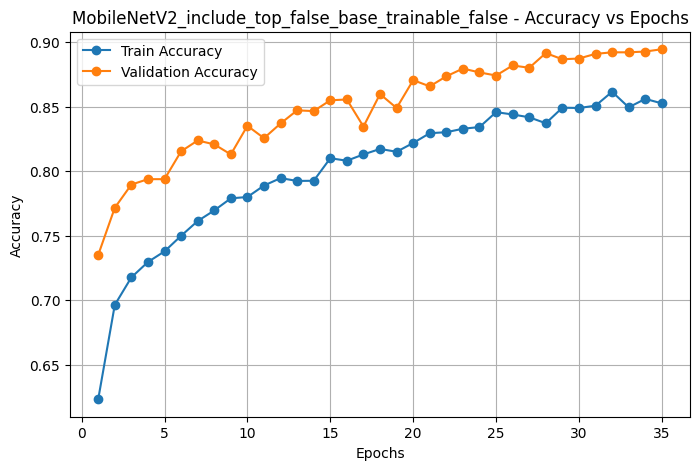

Saved: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/graphs/MobileNetV2_include_top_false_base_trainable_false_accuracy_vs_epochs.png


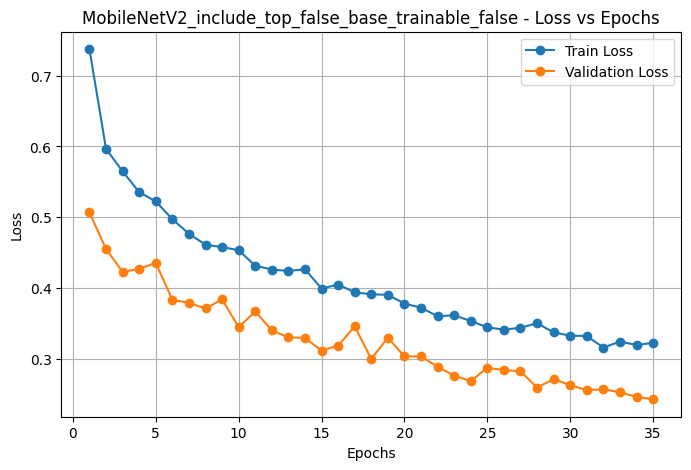

Saved: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/graphs/MobileNetV2_include_top_false_base_trainable_false_loss_vs_epochs.png


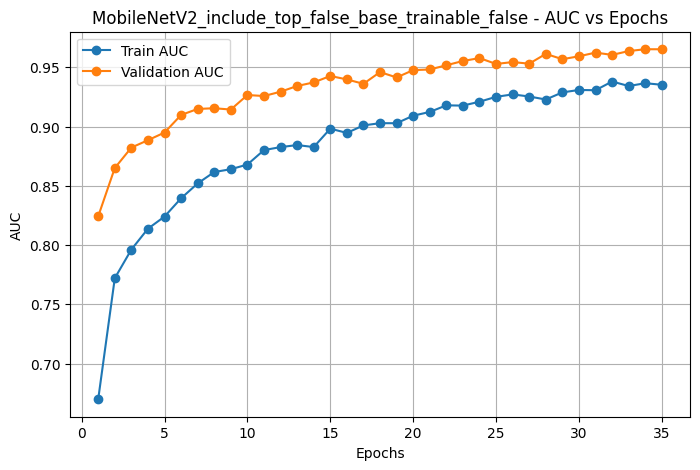

Saved: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/graphs/MobileNetV2_include_top_false_base_trainable_false_auc_vs_epochs.png
53/53 ━━━━━━━━━━━━━━━━━━━━ 692s 13s/step

MobileNetV2_include_top_false_base_trainable_false
Accuracy: 0.8890887290167866
F1 Score: 0.887401095556908
ROC AUC: 0.9630712696030226

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.88      0.90      0.89       834
   Parkinson       0.90      0.87      0.89       834

    accuracy                           0.89      1668
   macro avg       0.89      0.89      0.89      1668
weighted avg       0.89      0.89      0.89      1668


Confusion Matrix:
[[754  80]
 [105 729]]
Prediction data (y_true, y_pred, y_prob) saved: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/confusion_matrices/MobileNetV2_include_top_false_base_trainable_false_predictions.npz
Report saved: /content/drive/MyDrive/Colab Notebooks/Parkinson

<Figure size 600x600 with 0 Axes>

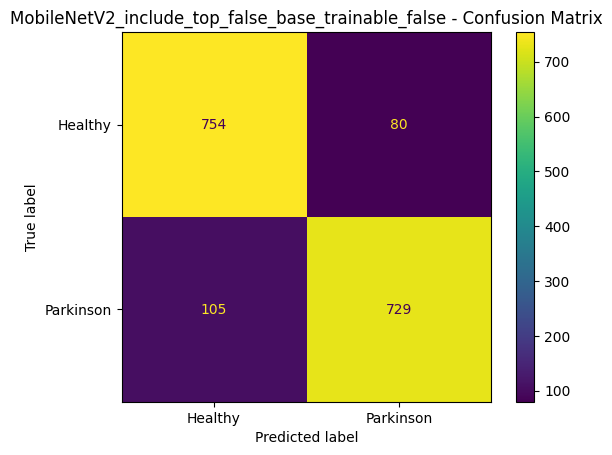

Confusion matrix image saved: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/confusion_matrices/MobileNetV2_include_top_false_base_trainable_false_confusion_matrix.png


In [17]:
model_name_1 = "MobileNetV2_include_top_false_base_trainable_false"

model_1 = build_mobilenetv2_model(base_trainable=False)

model_1.summary()

callbacks_1 = [
    EarlyStopping(
        monitor="val_auc",
        patience=7,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, f"{model_name_1}_best.keras"),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    CSVLogger(
        filename=os.path.join(HISTORY_DIR, f"{model_name_1}_training_log.csv")
    )
]

history_1 = model_1.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks_1
)

# Save final model
model_1_final_path = os.path.join(MODEL_DIR, f"{model_name_1}_final.keras")
model_1.save(model_1_final_path)
print("Final model saved:", model_1_final_path)

# Save history JSON
history_1_path = os.path.join(HISTORY_DIR, f"{model_name_1}_history.json")
os.makedirs(os.path.dirname(history_1_path), exist_ok=True)
with open(history_1_path, "w") as f:
    json.dump(history_1.history, f)

print("History saved:", history_1_path)

# Plot graphs
plot_training_history(history_1, model_name_1)

# Evaluate model
results_1 = evaluate_model(model_1, test_gen, model_name_1)

# Supplemental Analysis for `model_1`

This section contains the newly added code for saving ROC data, plotting training curves, and generating Grad-CAM visualizations for `model_1`, positioned after its training and evaluation.

In [18]:
# ==================================================
# PART 1 — SAVE ROC DATA (for model_1)
# ==================================================

print("\n--- Saving ROC Data for Model 1 ---")

# Ensure test_gen is reset before making predictions for y_prob
test_gen.reset()

# Get y_prob from model_1 predictions
y_prob_model_1 = model_1.predict(test_gen)

# Get y_true from the test generator
y_true_model_1 = test_gen.classes

# Define the NPZ file path as requested
roc_data_npz_path = os.path.join(ROC_DATA_DIR, "mobilenetv2_roc_data.npz")

# Save y_true and y_prob to the NPZ file
np.savez(
    roc_data_npz_path,
    y_true=y_true_model_1,
    y_prob=y_prob_model_1
)

print(f"Saved ROC data to: {roc_data_npz_path}")


--- Saving ROC Data for Model 1 ---
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step 
Saved ROC data to: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/ROC_DATA/mobilenetv2_roc_data.npz



--- Generating Training Curves for Model 1 ---


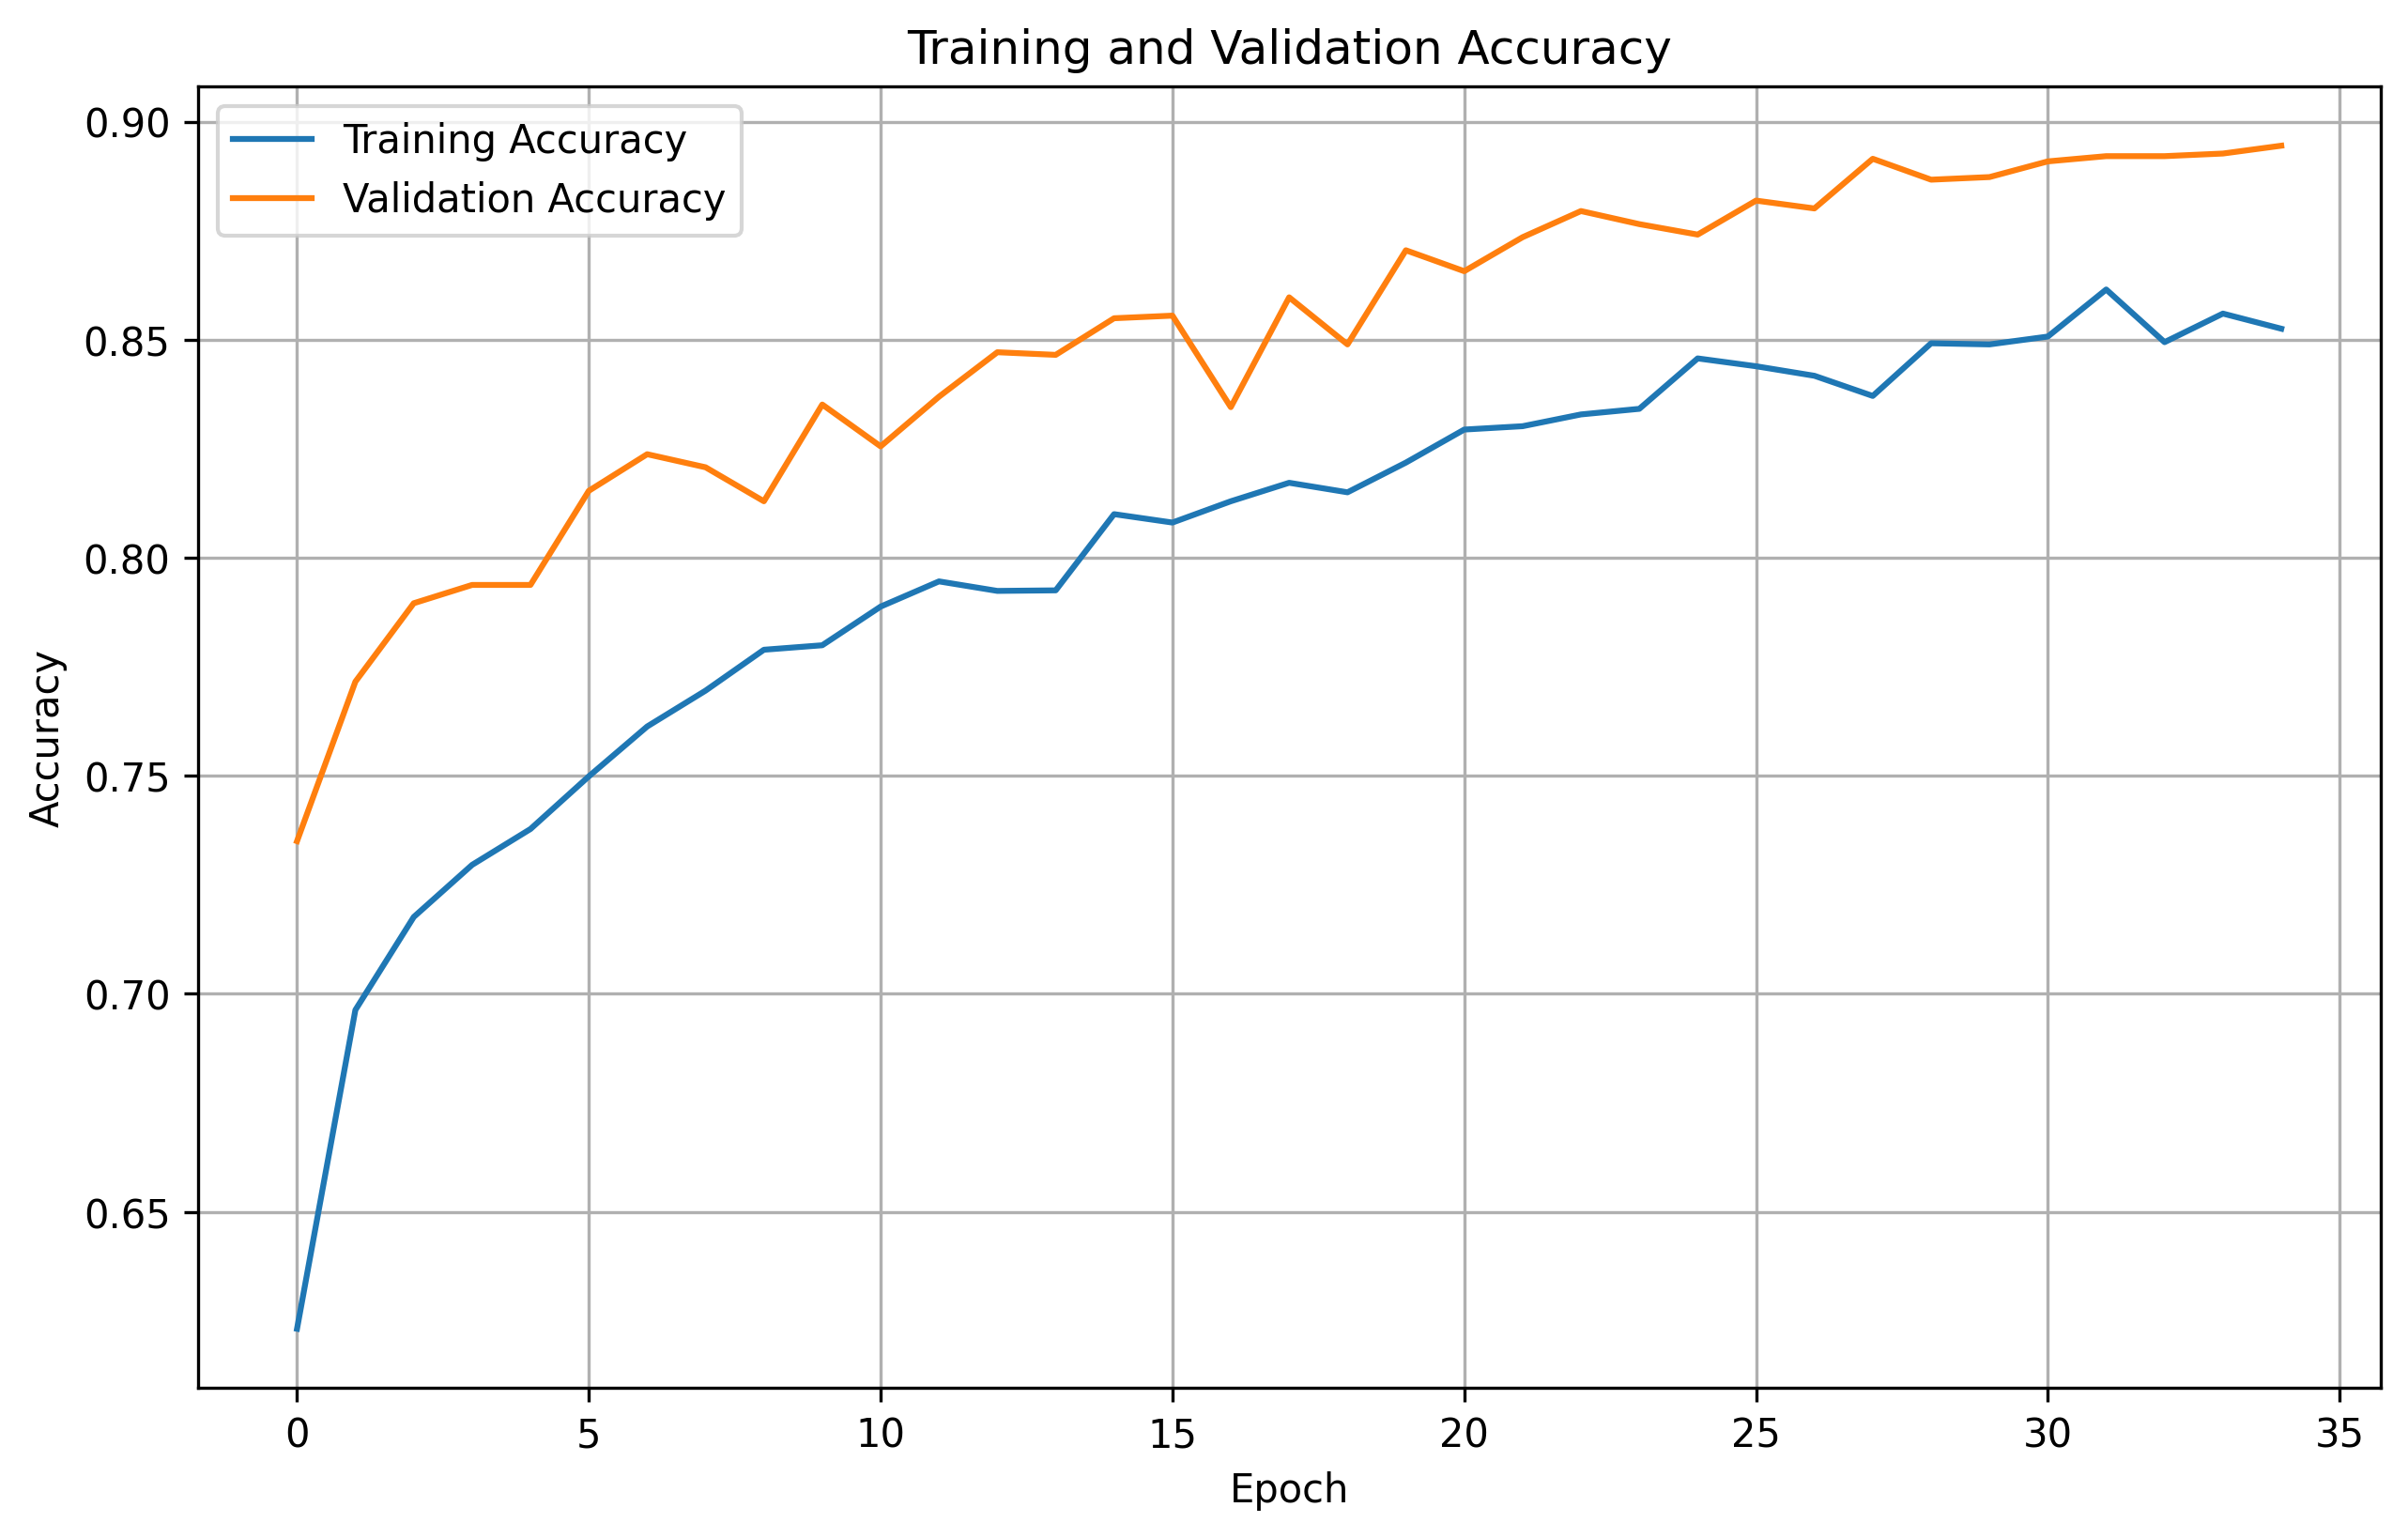

Saved Training Accuracy curve to: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/ROC_DATA/mobilenet_accuracy.png


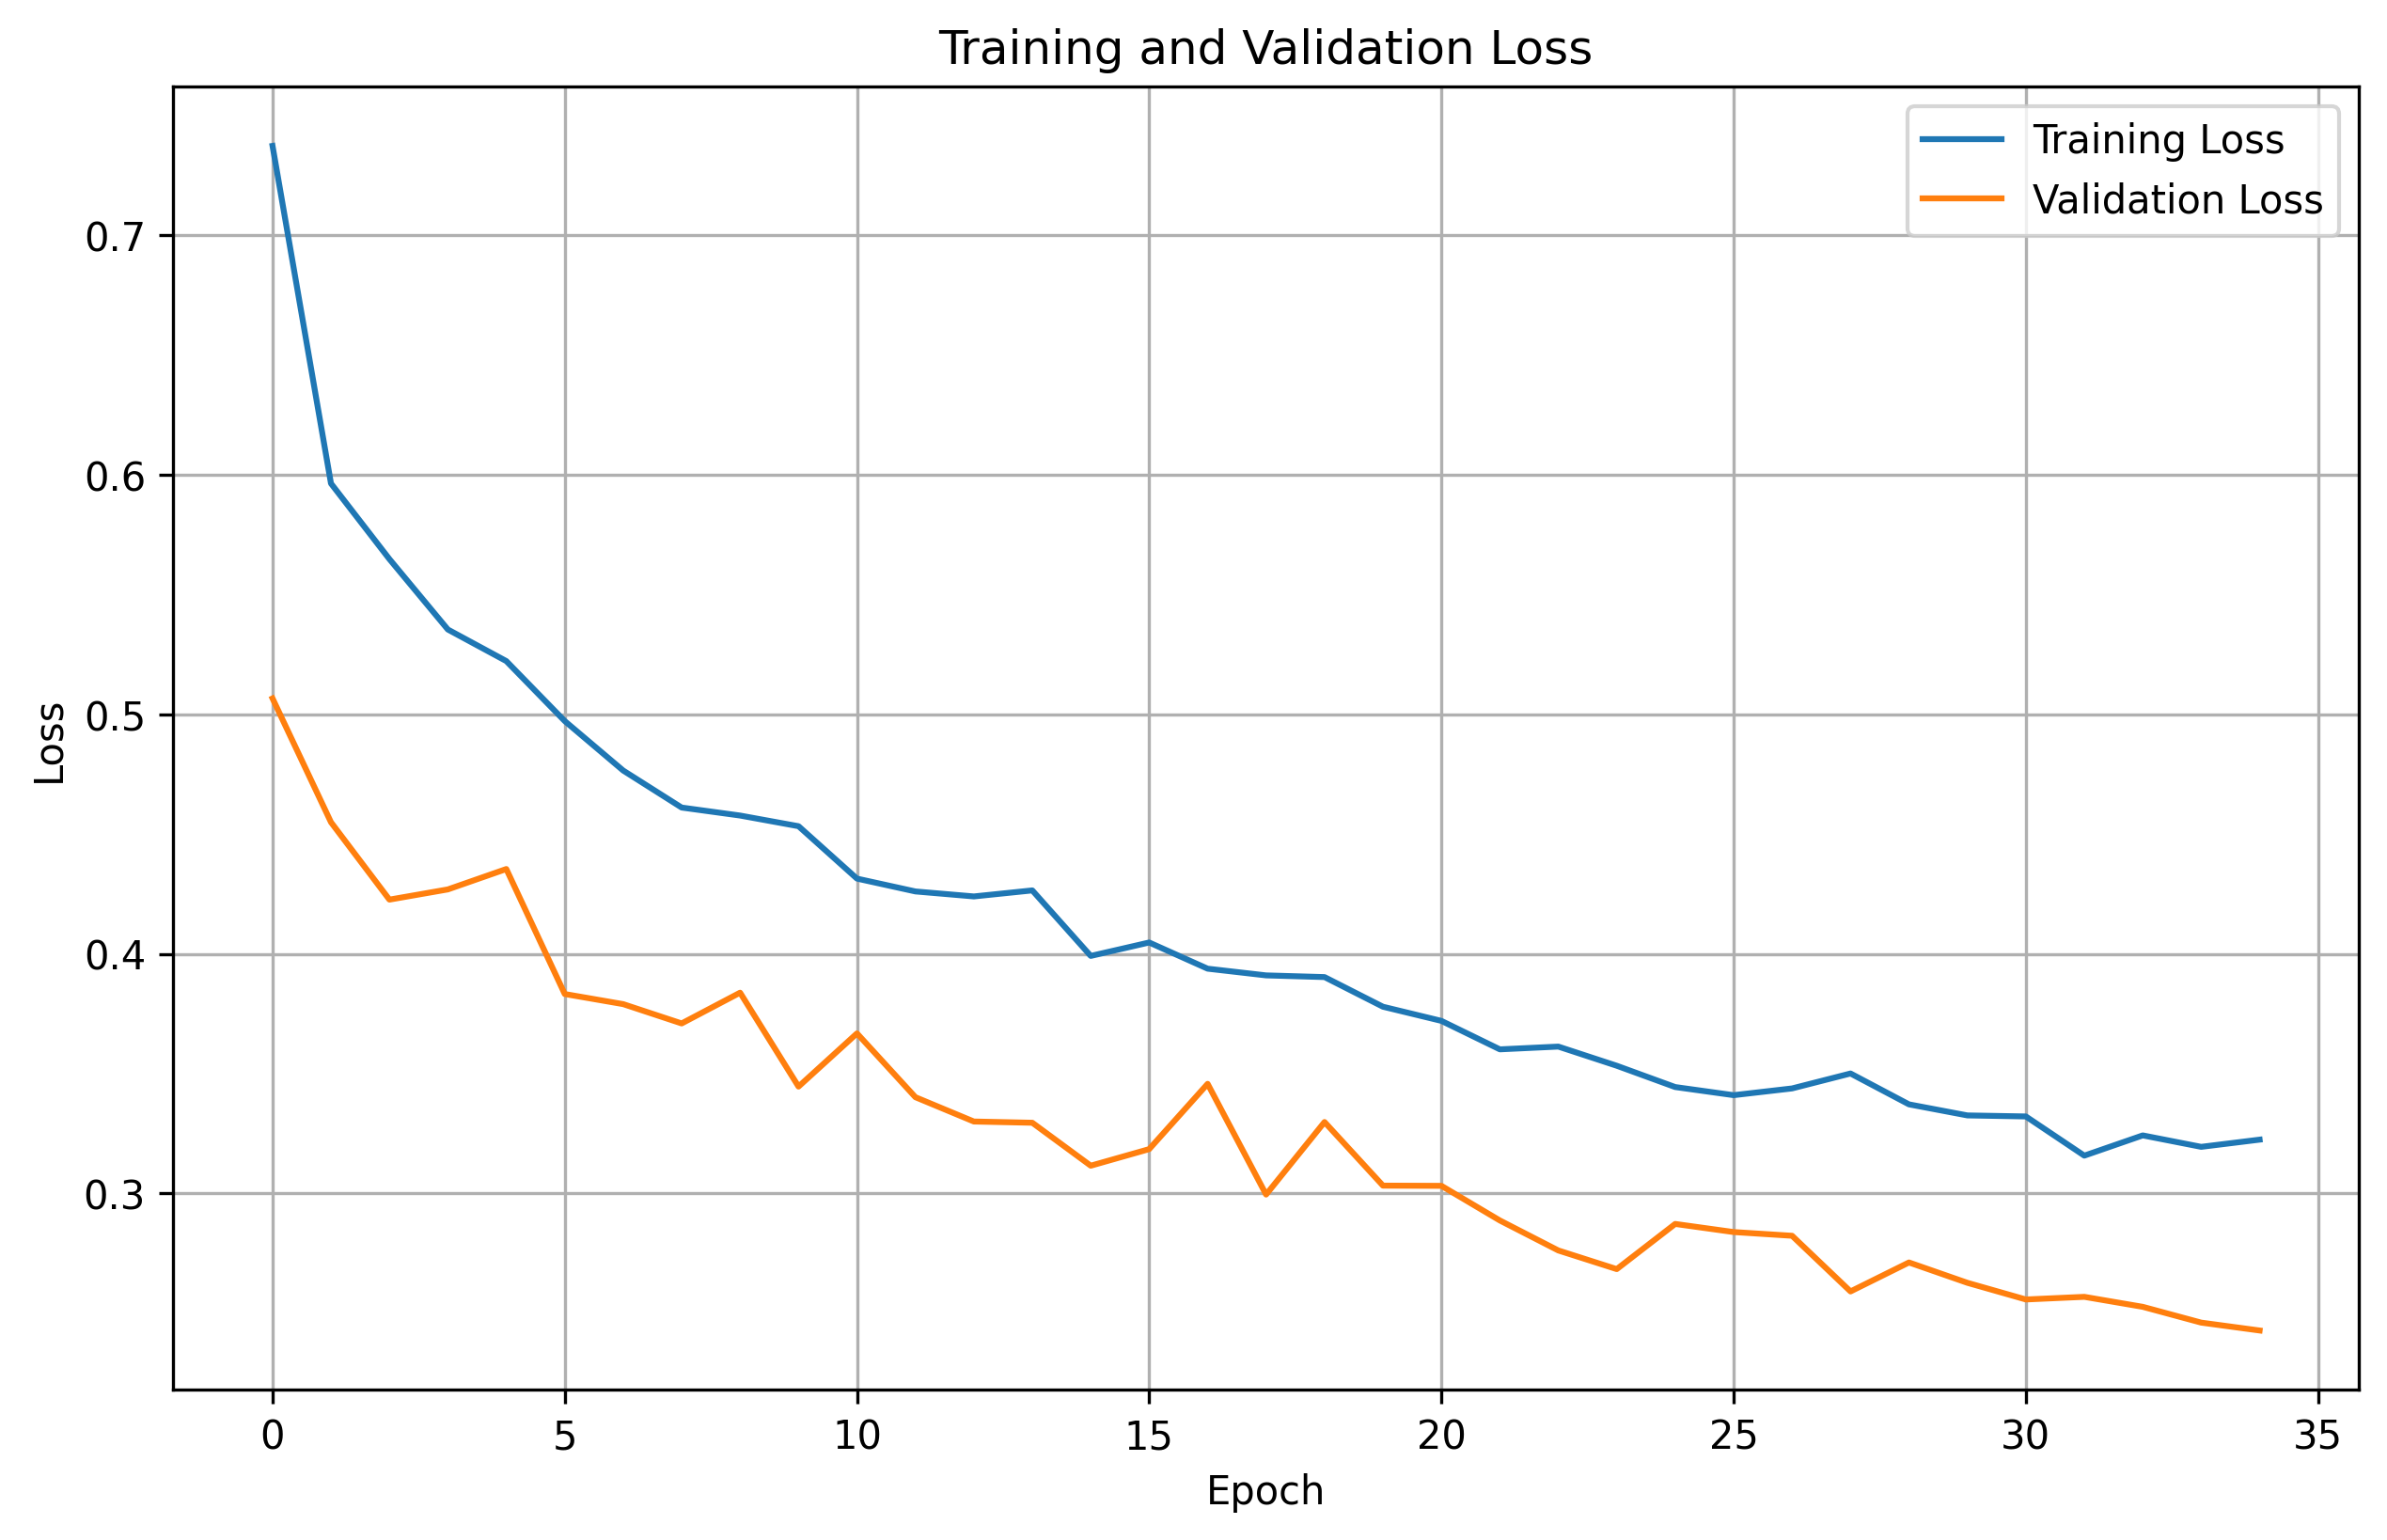

Saved Training Loss curve to: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/ROC_DATA/mobilenet_loss.png


In [19]:
# ==================================================
# PART 2 — TRAINING CURVES (for model_1)
# ==================================================

print("\n--- Generating Training Curves for Model 1 ---")

hist = history_1.history
epochs = range(1, len(hist["accuracy"]) + 1)

# 1. Training Accuracy and Validation Accuracy
plt.figure(figsize=(10, 6), dpi=300)
plt.plot(hist["accuracy"], label="Training Accuracy")
plt.plot(hist["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
accuracy_curve_path = os.path.join(ROC_DATA_DIR, "mobilenet_accuracy.png")
plt.savefig(accuracy_curve_path, bbox_inches="tight")
plt.show()
print(f"Saved Training Accuracy curve to: {accuracy_curve_path}")

# 2. Training Loss and Validation Loss
plt.figure(figsize=(10, 6), dpi=300)
plt.plot(hist["loss"], label="Training Loss")
plt.plot(hist["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
loss_curve_path = os.path.join(ROC_DATA_DIR, "mobilenet_loss.png")
plt.savefig(loss_curve_path, bbox_inches="tight")
plt.show()
print(f"Saved Training Loss curve to: {loss_curve_path}")

In [84]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


def display_gradcam(
    img_path,
    heatmap,
    alpha=0.40,
    pred_label=None,
    pred_confidence=None,
    true_label=None,
    save_path=None
):
    """
    Display:
      1. Original MRI
      2. Grad-CAM heatmap
      3. Grad-CAM overlay

    Fixes RGBA-versus-RGB broadcasting error.
    """

    # -------------------------------------------------
    # 1. Load the original MRI as RGB
    # -------------------------------------------------
    original_pil = Image.open(img_path).convert("RGB")

    original_pil = original_pil.resize(
        (224, 224),
        Image.Resampling.BILINEAR
    )

    original_img = np.asarray(
        original_pil,
        dtype=np.float32
    )

    # Normalize the display image to [0, 1]
    if original_img.max() > 1.0:
        original_img = original_img / 255.0

    # -------------------------------------------------
    # 2. Prepare and resize the heatmap
    # -------------------------------------------------
    heatmap = np.asarray(
        heatmap,
        dtype=np.float32
    )

    heatmap = np.squeeze(heatmap)

    heatmap = np.nan_to_num(
        heatmap,
        nan=0.0,
        posinf=1.0,
        neginf=0.0
    )

    heatmap = np.maximum(heatmap, 0)

    heatmap_max = float(np.max(heatmap))

    if heatmap_max > 1e-12:
        heatmap = heatmap / heatmap_max
    else:
        heatmap = np.zeros_like(
            heatmap,
            dtype=np.float32
        )
        print("Warning: Zero Grad-CAM heatmap detected.")

    heatmap_pil = Image.fromarray(
        np.uint8(255 * heatmap)
    )

    heatmap_pil = heatmap_pil.resize(
        (224, 224),
        Image.Resampling.BILINEAR
    )

    resized_heatmap = (
        np.asarray(heatmap_pil, dtype=np.float32) / 255.0
    )

    # -------------------------------------------------
    # 3. Convert the heatmap to RGB
    # -------------------------------------------------
    # New Matplotlib API; avoids get_cmap deprecation.
    colormap = plt.colormaps["jet"]

    # Colormap returns RGBA: H x W x 4
    rgba_heatmap = colormap(resized_heatmap)

    # Remove the alpha channel: H x W x 3
    rgb_heatmap = rgba_heatmap[..., :3].astype(np.float32)

    # -------------------------------------------------
    # 4. Produce the overlay
    # -------------------------------------------------
    overlay = (
        (1.0 - alpha) * original_img
        + alpha * rgb_heatmap
    )

    overlay = np.clip(
        overlay,
        0.0,
        1.0
    )

    print("Original image shape:", original_img.shape)
    print("Colored heatmap shape:", rgb_heatmap.shape)
    print("Overlay shape:", overlay.shape)

    # -------------------------------------------------
    # 5. Plot
    # -------------------------------------------------
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )

    axes[0].imshow(original_img)
    axes[0].set_title(
        f"Original MRI\nTrue: {true_label}"
        if true_label is not None
        else "Original MRI"
    )
    axes[0].axis("off")

    heatmap_plot = axes[1].imshow(
        resized_heatmap,
        cmap="jet",
        vmin=0,
        vmax=1
    )
    axes[1].set_title("MobileNetV2 Grad-CAM Heatmap")
    axes[1].axis("off")

    fig.colorbar(
        heatmap_plot,
        ax=axes[1],
        fraction=0.046,
        pad=0.04
    )

    prediction_title = "Grad-CAM Overlay"

    if pred_label is not None:
        prediction_title += f"\nPredicted: {pred_label}"

    if pred_confidence is not None:
        prediction_title += (
            f" ({float(pred_confidence):.2f}%)"
        )

    axes[2].imshow(overlay)
    axes[2].set_title(prediction_title)
    axes[2].axis("off")

    plt.tight_layout()

    # -------------------------------------------------
    # 6. Save
    # -------------------------------------------------
    if save_path is not None:
        os.makedirs(
            os.path.dirname(save_path),
            exist_ok=True
        )

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

        print("Saved Grad-CAM figure to:")
        print(save_path)

    plt.show()

    return overlay

In [106]:
import numpy as np

# Extract Parkinson probability from the model prediction
parkinson_probability = float(np.asarray(preds).reshape(-1)[0])

# Convert probability into predicted label and confidence
if parkinson_probability >= 0.5:
    predicted_label = "Parkinson"
    confidence = parkinson_probability * 100.0
else:
    predicted_label = "Healthy"
    confidence = (1.0 - parkinson_probability) * 100.0

print(f"Parkinson probability: {parkinson_probability:.8f}")
print(f"Predicted label: {predicted_label}")
print(f"Confidence: {confidence:.2f}%")

Parkinson probability: 0.00000342
Predicted label: Healthy
Confidence: 100.00%



>>> FIXED display_gradcam VERSION 4 IS RUNNING <<<
Original image shape: (224, 224, 3)
RGBA heatmap shape: (224, 224, 4)
RGB heatmap shape: (224, 224, 3)
Overlay shape: (224, 224, 3)
Saved corrected Grad-CAM:
/content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/grad_cam_outputs/mobilenet_single_image_gradcam_FIXED.png


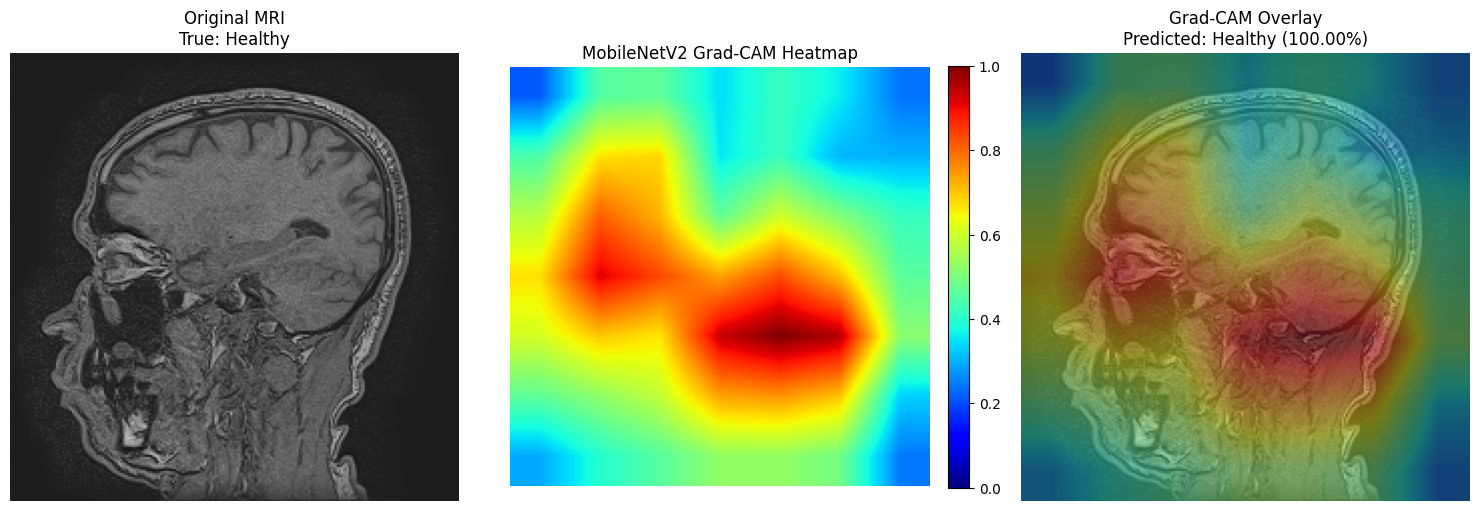

In [107]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras


# This intentionally uses the SAME function name as the old function.
# It overwrites the old function in Colab memory.
def display_gradcam(
    img_path,
    heatmap,
    alpha=0.40,
    pred_label=None,
    pred_confidence=None,
    true_label=None,
    save_path=None
):
    print("\n>>> FIXED display_gradcam VERSION 4 IS RUNNING <<<")

    # --------------------------------------------------
    # 1. Load the MRI as an RGB image
    # --------------------------------------------------
    original_img = keras.utils.load_img(
        img_path,
        target_size=(224, 224),
        color_mode="rgb"
    )

    original_img = keras.utils.img_to_array(
        original_img
    ).astype(np.float32)

    original_img = original_img / 255.0

    # --------------------------------------------------
    # 2. Prepare the 7×7 Grad-CAM heatmap
    # --------------------------------------------------
    heatmap_array = np.asarray(
        heatmap,
        dtype=np.float32
    )

    heatmap_array = np.squeeze(heatmap_array)

    heatmap_array = np.nan_to_num(
        heatmap_array,
        nan=0.0,
        posinf=1.0,
        neginf=0.0
    )

    heatmap_array = np.maximum(
        heatmap_array,
        0.0
    )

    maximum = float(np.max(heatmap_array))

    if maximum > 1e-12:
        heatmap_array = heatmap_array / maximum
    else:
        heatmap_array = np.zeros_like(
            heatmap_array,
            dtype=np.float32
        )
        print("Warning: zero heatmap detected.")

    # Resize 7×7 to 224×224
    resized_heatmap = tf.image.resize(
        heatmap_array[np.newaxis, ..., np.newaxis],
        size=(224, 224),
        method="bilinear"
    )[0, ..., 0].numpy()

    resized_heatmap = np.clip(
        resized_heatmap,
        0.0,
        1.0
    )

    # --------------------------------------------------
    # 3. Convert the heatmap from RGBA to RGB
    # --------------------------------------------------
    colormap = plt.colormaps.get_cmap("jet")

    rgba_heatmap = colormap(resized_heatmap)

    # Remove the fourth alpha channel
    rgb_heatmap = rgba_heatmap[..., :3].astype(
        np.float32
    )

    print("Original image shape:", original_img.shape)
    print("RGBA heatmap shape:", rgba_heatmap.shape)
    print("RGB heatmap shape:", rgb_heatmap.shape)

    if original_img.shape != rgb_heatmap.shape:
        raise ValueError(
            f"Shape mismatch remains: "
            f"image={original_img.shape}, "
            f"heatmap={rgb_heatmap.shape}"
        )

    # --------------------------------------------------
    # 4. Create the overlay
    # --------------------------------------------------
    overlay = (
        (1.0 - alpha) * original_img
        + alpha * rgb_heatmap
    )

    overlay = np.clip(
        overlay,
        0.0,
        1.0
    )

    print("Overlay shape:", overlay.shape)

    # --------------------------------------------------
    # 5. Format confidence
    # --------------------------------------------------
    confidence_text = ""

    if pred_confidence is not None:
        confidence_value = float(pred_confidence)

        if confidence_value <= 1.0:
            confidence_value *= 100.0

        confidence_text = f" ({confidence_value:.2f}%)"

    # --------------------------------------------------
    # 6. Display
    # --------------------------------------------------
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )

    axes[0].imshow(original_img)
    axes[0].set_title(
        f"Original MRI\nTrue: {true_label}"
    )
    axes[0].axis("off")

    heatmap_plot = axes[1].imshow(
        resized_heatmap,
        cmap="jet",
        vmin=0,
        vmax=1
    )
    axes[1].set_title(
        "MobileNetV2 Grad-CAM Heatmap"
    )
    axes[1].axis("off")

    fig.colorbar(
        heatmap_plot,
        ax=axes[1],
        fraction=0.046,
        pad=0.04
    )

    axes[2].imshow(overlay)
    axes[2].set_title(
        f"Grad-CAM Overlay\n"
        f"Predicted: {pred_label}{confidence_text}"
    )
    axes[2].axis("off")

    plt.tight_layout()

    # --------------------------------------------------
    # 7. Save
    # --------------------------------------------------
    if save_path is not None:
        save_folder = os.path.dirname(save_path)

        if save_folder:
            os.makedirs(
                save_folder,
                exist_ok=True
            )

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

        print("Saved corrected Grad-CAM:")
        print(save_path)

    plt.show()

    return overlay


# ==================================================
# CALL THE FIXED FUNCTION IMMEDIATELY
# ==================================================

single_gradcam_save_path = os.path.join(
    GRADCAM_DIR,
    "mobilenet_single_image_gradcam_FIXED.png"
)

fixed_overlay = display_gradcam(
    img_path=single_image_path,
    heatmap=heatmap,
    alpha=0.40,
    pred_label=predicted_label,
    pred_confidence=confidence,
    true_label="Healthy",
    save_path=single_gradcam_save_path
)


--- Generating Multiple Image Grad-CAM Examples ---

Processing image 9828/4: PPMI_100890_MR_3D_T1-weighted_br_raw_20210916214027681_1_S1063522_I1493049_slice_136.png
Backbone: mobilenetv2_1.00_224
Last convolution layer: Conv_1
Model input shape: (1, 224, 224, 3)
Convolution output shape: (1, 7, 7, 1280)
Prediction: [[0.03636466]]
Gradient minimum: -0.03351464122533798
Gradient maximum: 0.032362986356019974
Gradient norm: 0.9289631247520447
Heatmap minimum: 0.0
Heatmap maximum: 1.0
Original MRI shape: (224, 224, 3)
Colored heatmap shape: (224, 224, 3)
Overlay shape: (224, 224, 3)
Grad-CAM saved to:
/content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/grad_cam_outputs/healthy_PPMI_100890_MR_3D_T1-weighted_br_raw_20210916214027681_1_S1063522_I1493049_slice_136_png_gradcam.png


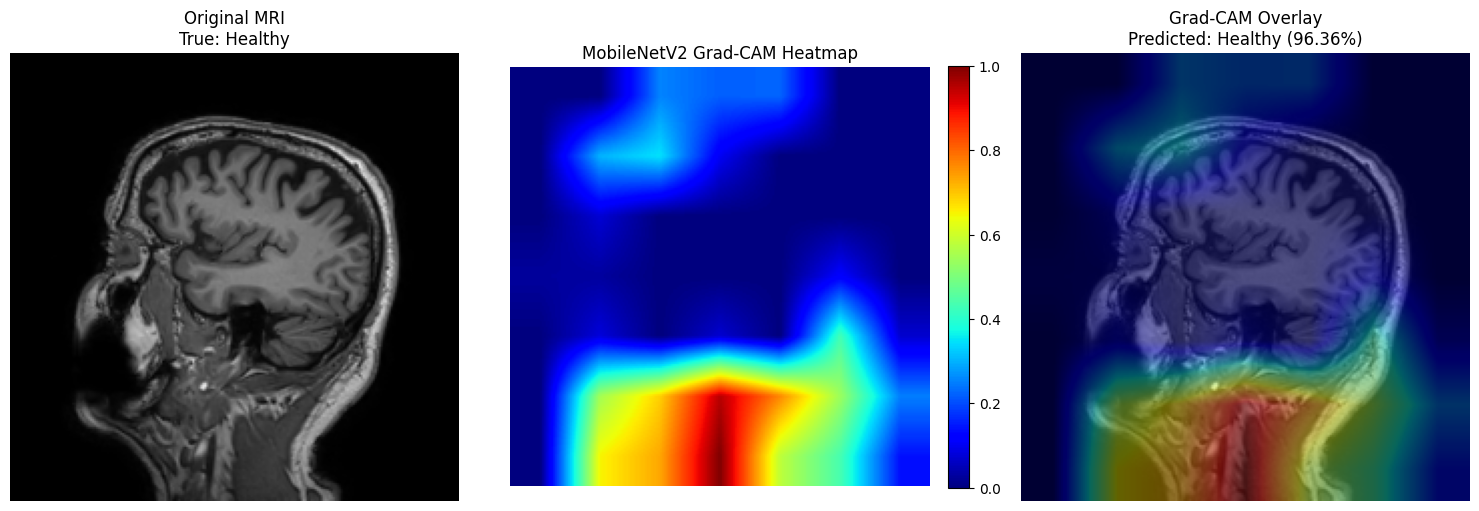


Processing image 8060/4: PPMI_149716_MR_3D_T1_MPRAGE_br_raw_20220520053803199_76_S1134998_I1582625.png
Backbone: mobilenetv2_1.00_224
Last convolution layer: Conv_1
Model input shape: (1, 224, 224, 3)
Convolution output shape: (1, 7, 7, 1280)
Prediction: [[0.00188361]]
Gradient minimum: -0.03357014060020447
Gradient maximum: 0.029173698276281357
Gradient norm: 0.9593883156776428
Heatmap minimum: 0.0
Heatmap maximum: 1.0
Original MRI shape: (224, 224, 3)
Colored heatmap shape: (224, 224, 3)
Overlay shape: (224, 224, 3)
Grad-CAM saved to:
/content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/grad_cam_outputs/healthy_PPMI_149716_MR_3D_T1_MPRAGE_br_raw_20220520053803199_76_S1134998_I1582625_png_gradcam.png


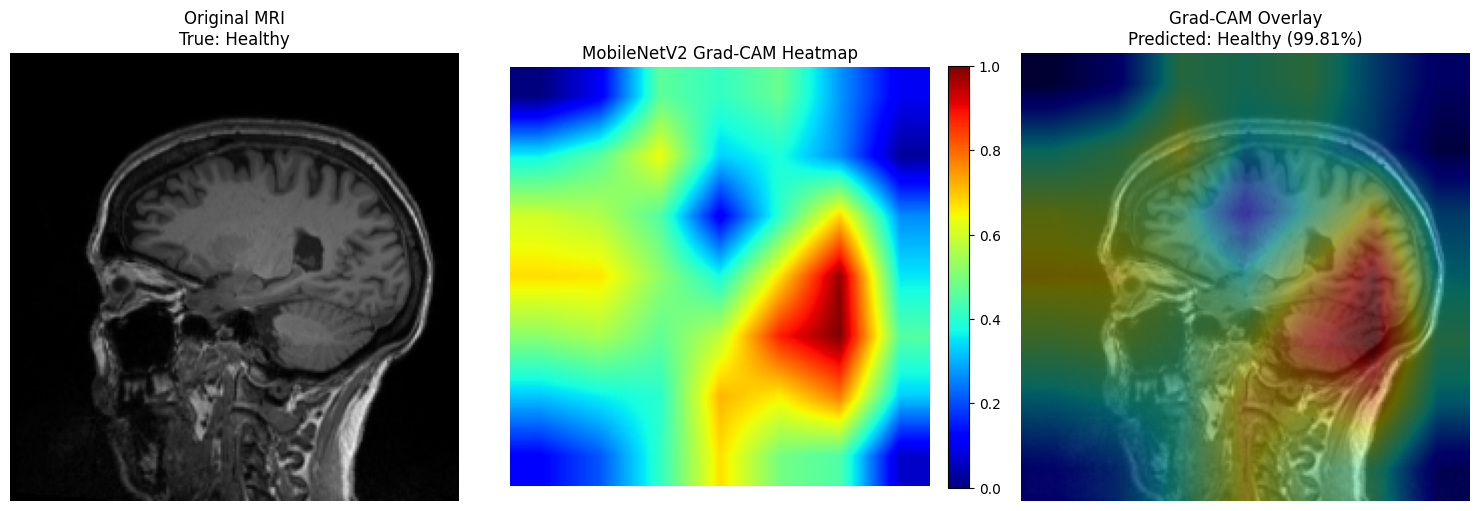


Processing image 6094/4: PPMI_101187_MR_SAG_3D_T1_FSPGR__br_raw_20210924163323179_62_S1066224_I1496300.png
Backbone: mobilenetv2_1.00_224
Last convolution layer: Conv_1
Model input shape: (1, 224, 224, 3)
Convolution output shape: (1, 7, 7, 1280)
Prediction: [[0.965895]]
Gradient minimum: -0.05001920834183693
Gradient maximum: 0.04315422102808952
Gradient norm: 1.4403996467590332
Heatmap minimum: 0.0
Heatmap maximum: 1.0
Original MRI shape: (224, 224, 3)
Colored heatmap shape: (224, 224, 3)
Overlay shape: (224, 224, 3)
Grad-CAM saved to:
/content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/grad_cam_outputs/parkinson_PPMI_101187_MR_SAG_3D_T1_FSPGR__br_raw_20210924163323179_62_S1066224_I1496300_png_gradcam.png


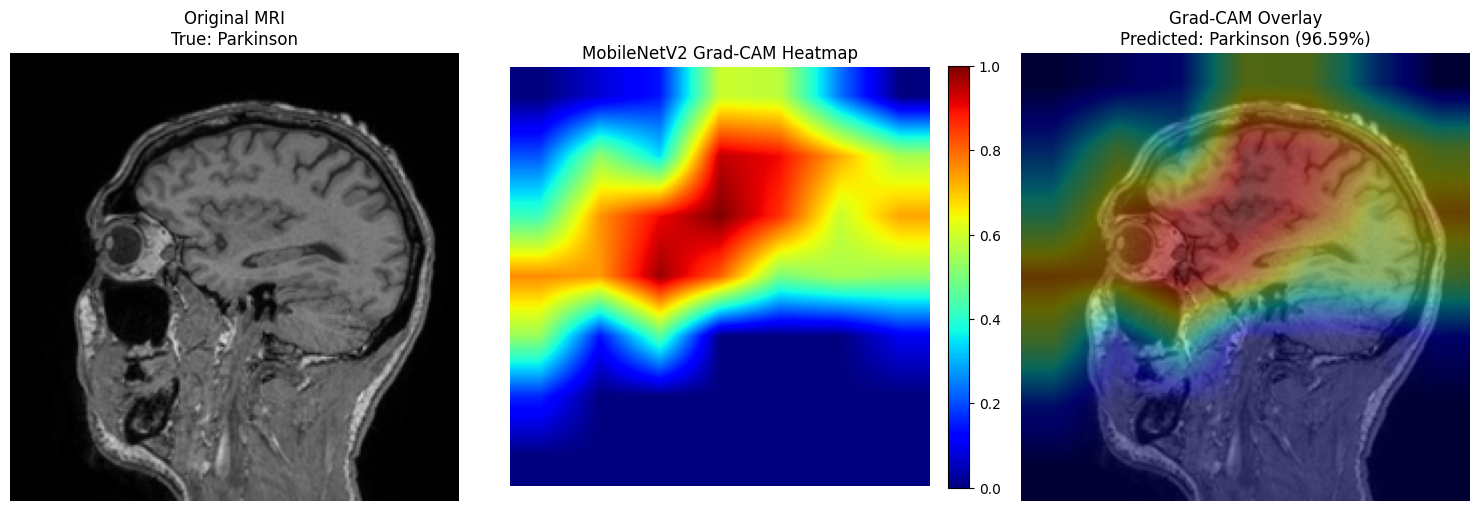


Processing image 780/4: PPMI_100889_MR_3D_T1-weighted_br_raw_20220923105341523_1_S1160630_I1622593_slice_036.png
Backbone: mobilenetv2_1.00_224
Last convolution layer: Conv_1
Model input shape: (1, 224, 224, 3)
Convolution output shape: (1, 7, 7, 1280)
Prediction: [[0.9987571]]
Gradient minimum: -0.03218705952167511
Gradient maximum: 0.04214775562286377
Gradient norm: 1.0923627614974976
Heatmap minimum: 0.0
Heatmap maximum: 1.0
Original MRI shape: (224, 224, 3)
Colored heatmap shape: (224, 224, 3)
Overlay shape: (224, 224, 3)
Grad-CAM saved to:
/content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/grad_cam_outputs/parkinson_PPMI_100889_MR_3D_T1-weighted_br_raw_20220923105341523_1_S1160630_I1622593_slice_036_png_gradcam.png


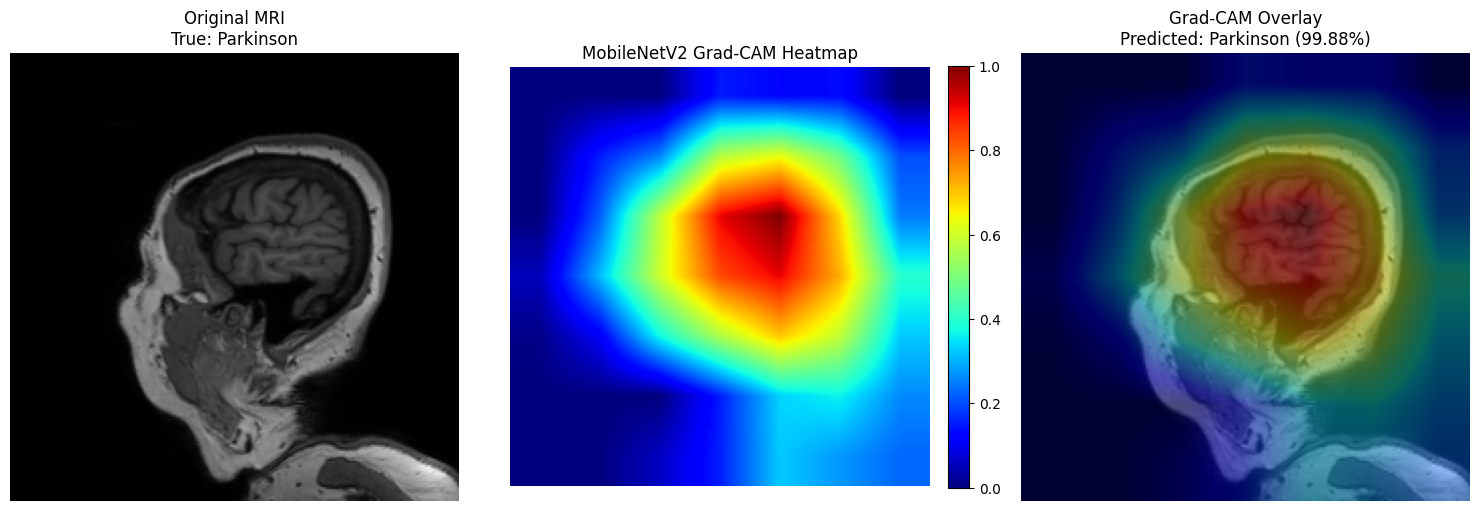

In [95]:
# ==================================================
# PART 4 — MULTIPLE EXAMPLES GRAD-CAM
# ==================================================

print("\n--- Generating Multiple Image Grad-CAM Examples ---")

# Select 2 Healthy and 2 Parkinson images from the test set
healthy_images_df = test_df[test_df['label'] == '0'].sample(2, random_state=101) # Using a different random state
parkinson_images_df = test_df[test_df['label'] == '1'].sample(2, random_state=102)

multiple_images_df = pd.concat([healthy_images_df, parkinson_images_df])

for i, row in multiple_images_df.iterrows():
    img_path = row['image_path']
    true_label = row['label']

    print(f"\nProcessing image {i+1}/{len(multiple_images_df)}: {os.path.basename(img_path)}")

    # Preprocess image
    img_array = get_img_array(img_path, size=(IMG_SIZE, IMG_SIZE))

    # Generate heatmap using the new function `make_mobilenet_gradcam`
    heatmap, preds = make_mobilenet_gradcam(img_array, model_1, LAST_CONV_LAYER_NAME)

    # Get prediction details (adjusting for binary sigmoid output)
    predicted_prob_parkinson = preds[0]
    if predicted_prob_parkinson > 0.5:
        predicted_label = "Parkinson"
        predicted_confidence = predicted_prob_parkinson * 100
    else:
        predicted_label = "Healthy"
        predicted_confidence = (1 - predicted_prob_parkinson) * 100

    # Display and save Grad-CAM
    filename_prefix = "healthy" if true_label == '0' else "parkinson"
    multiple_gradcam_save_path = os.path.join(
        GRADCAM_DIR,
        f"{filename_prefix}_{os.path.basename(img_path).replace('.', '_')}_gradcam.png"
    )
    display_gradcam(
        img_path, heatmap,
        pred_label=predicted_label,
        pred_confidence=predicted_confidence[0], # Access the scalar value
        true_label=('Healthy' if true_label == '0' else 'Parkinson'),
        save_path=multiple_gradcam_save_path
    )

In [96]:
# ==================================================
# PART 1 — SAVE ROC DATA (for model_1)
# ==================================================

print("\n--- Saving ROC Data for Model 1 ---")

# Ensure test_gen is reset before making predictions for y_prob
test_gen.reset()

# Get y_prob from model_1 predictions
y_prob_model_1 = model_1.predict(test_gen)

# Get y_true from the test generator
y_true_model_1 = test_gen.classes

# Define the NPZ file path as requested
roc_data_npz_path = os.path.join(ROC_DATA_DIR, "mobilenetv2_roc_data.npz")

# Save y_true and y_prob to the NPZ file
np.savez(
    roc_data_npz_path,
    y_true=y_true_model_1,
    y_prob=y_prob_model_1
)

print(f"Saved ROC data to: {roc_data_npz_path}")


--- Saving ROC Data for Model 1 ---
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step
Saved ROC data to: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/ROC_DATA/mobilenetv2_roc_data.npz



--- Generating Training Curves for Model 1 ---


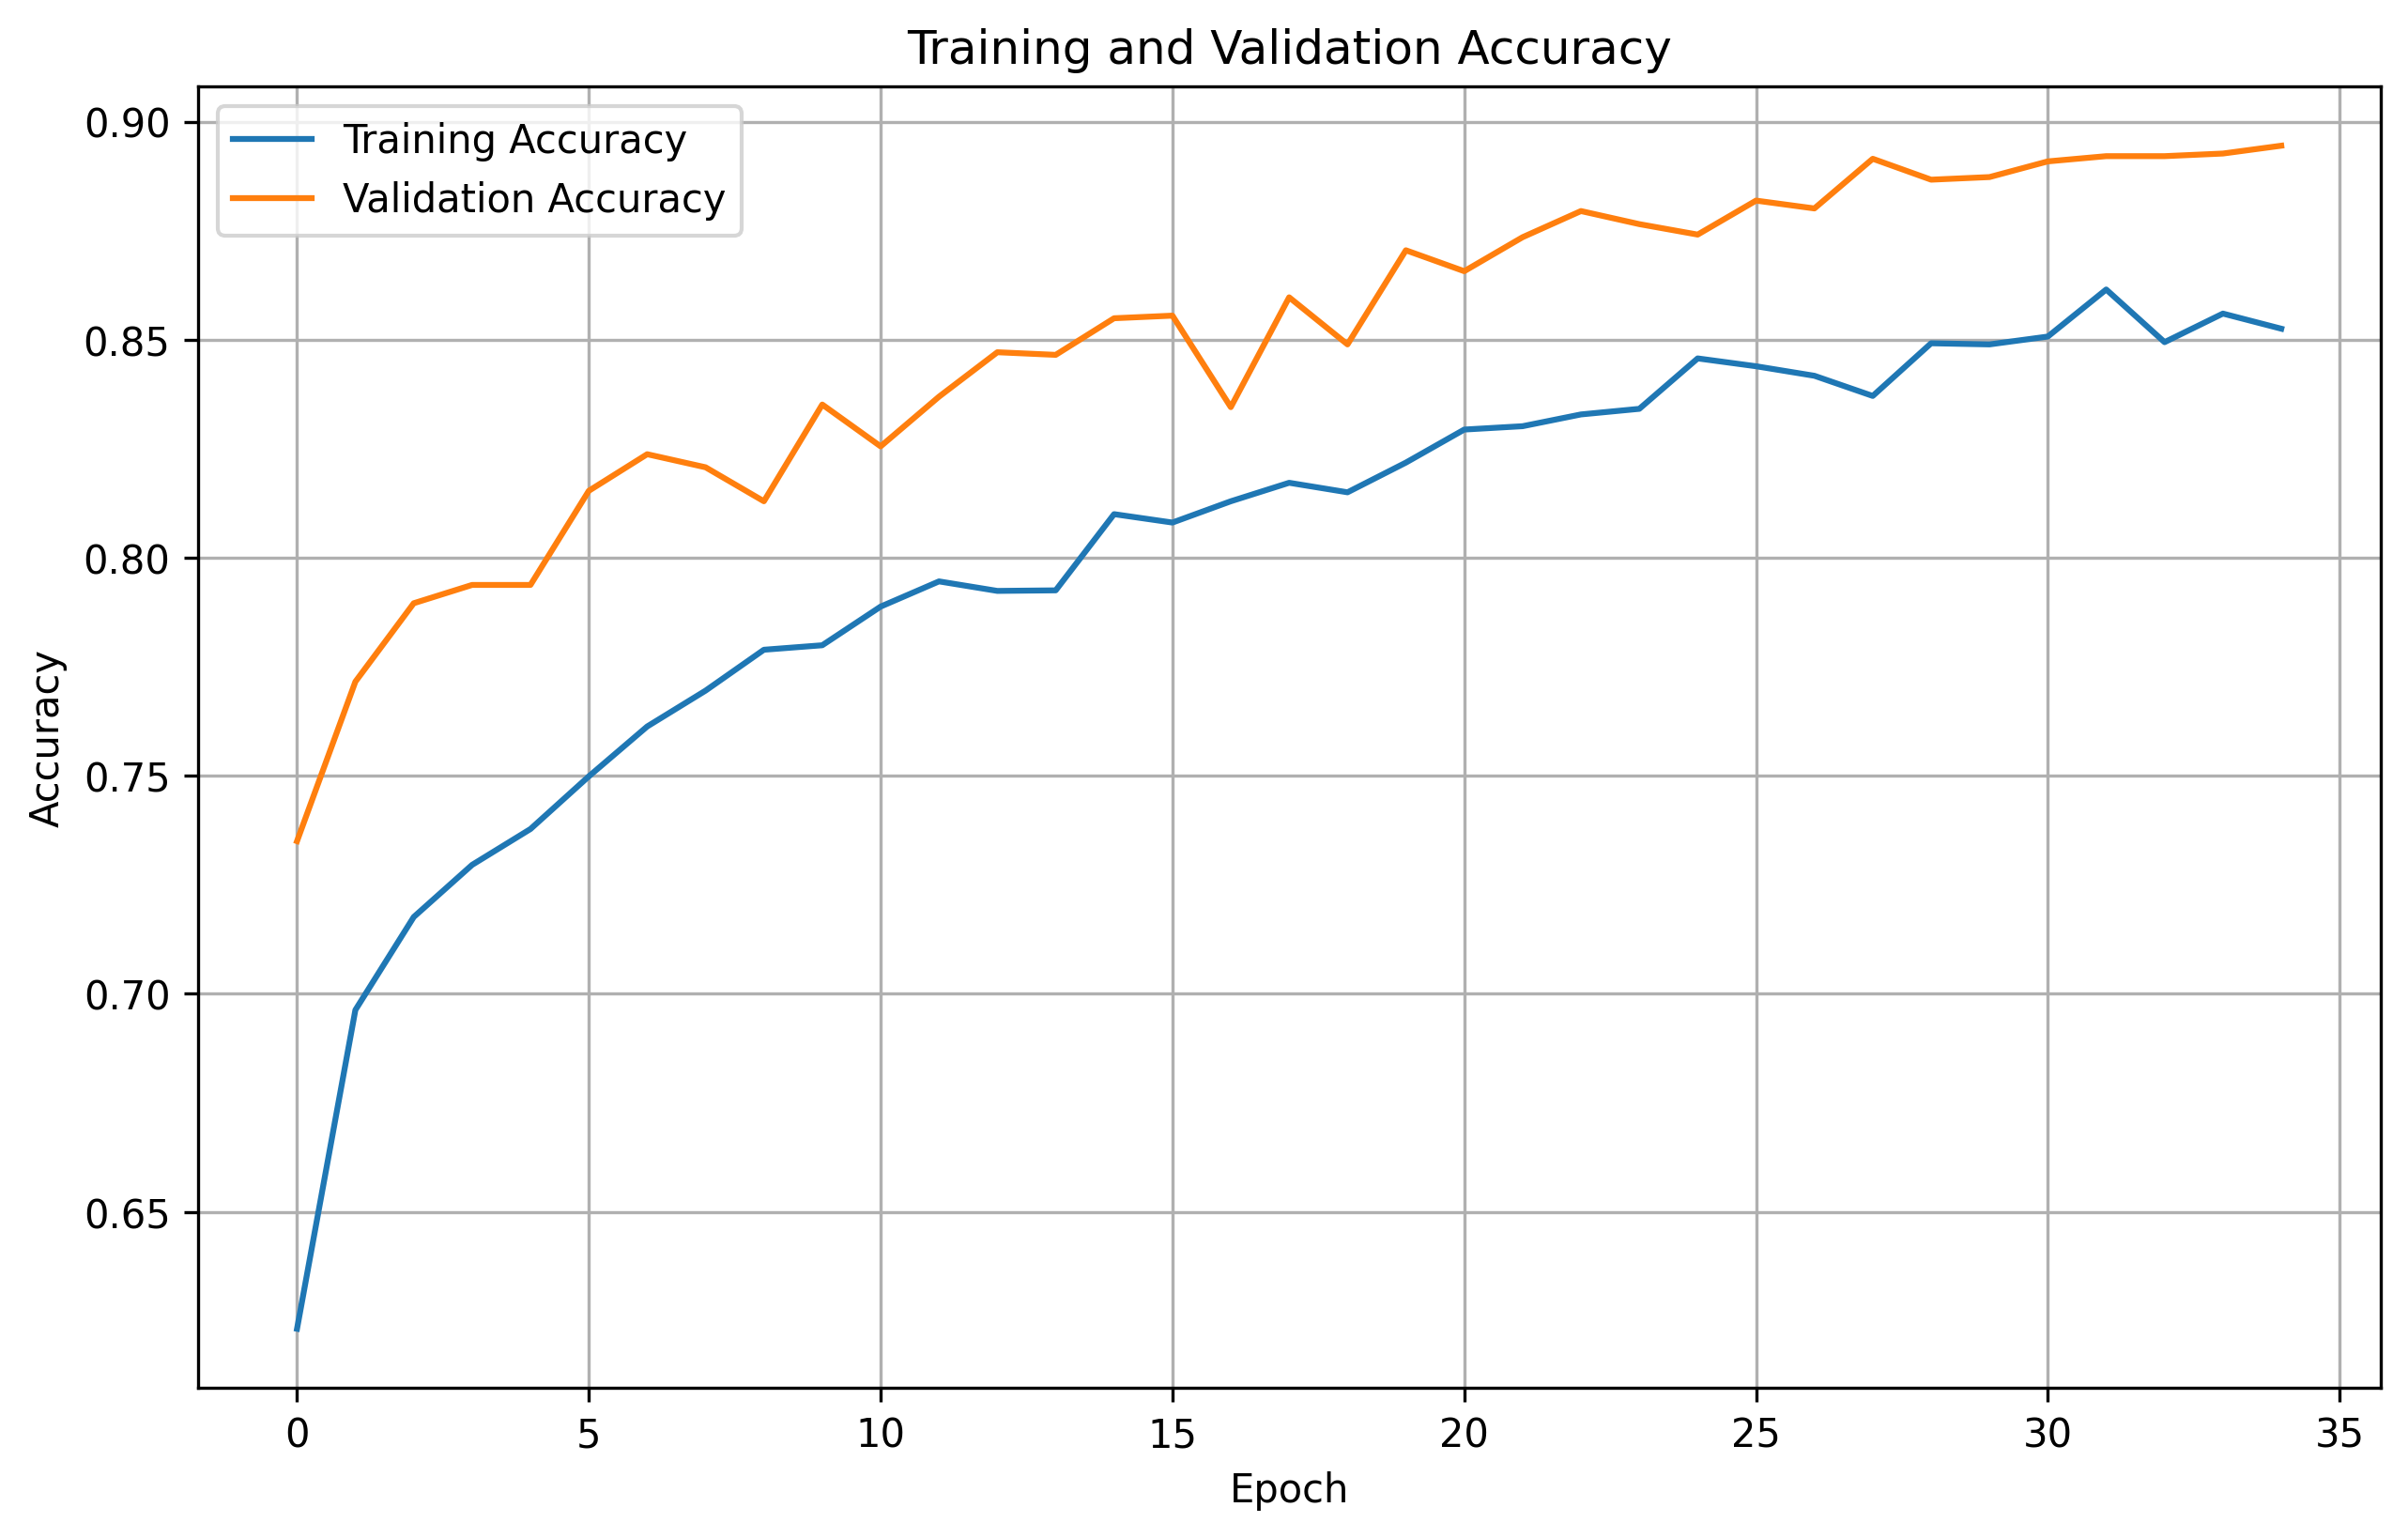

Saved Training Accuracy curve to: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/ROC_DATA/mobilenet_accuracy.png


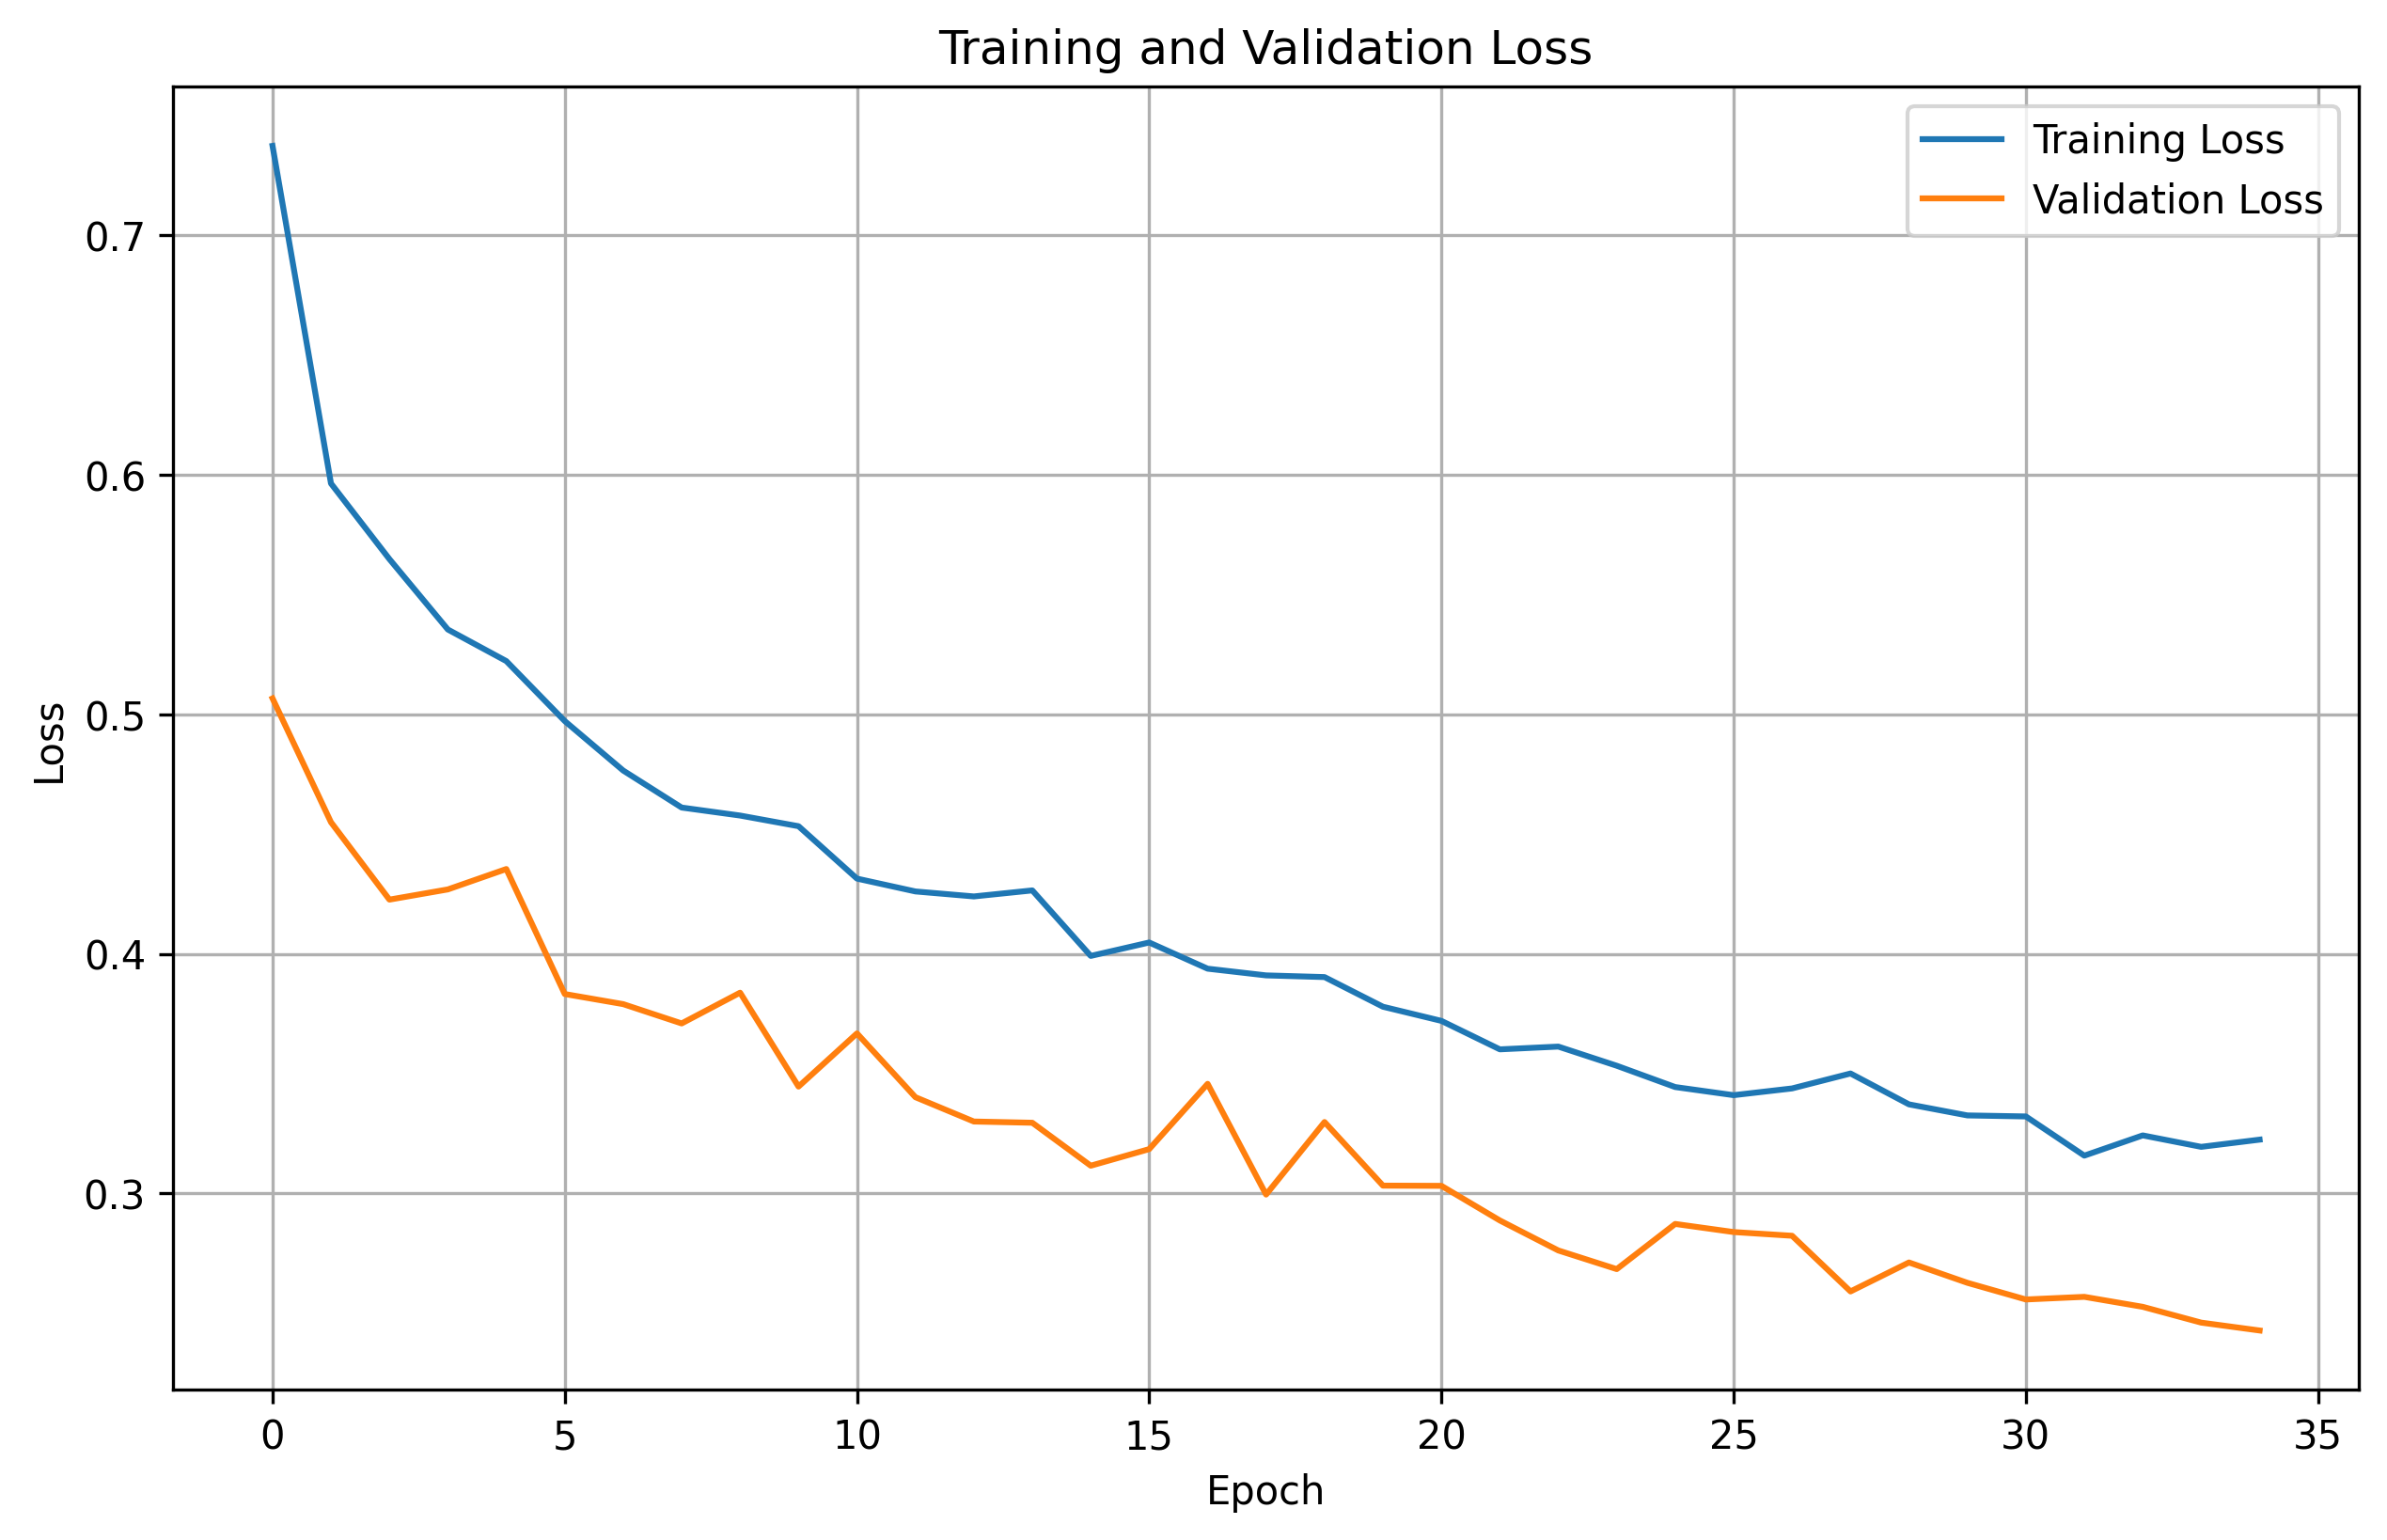

Saved Training Loss curve to: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/ROC_DATA/mobilenet_loss.png


In [97]:
# ==================================================
# PART 2 — TRAINING CURVES (for model_1)
# ==================================================

print("\n--- Generating Training Curves for Model 1 ---")

hist = history_1.history
epochs = range(1, len(hist["accuracy"]) + 1)

# 1. Training Accuracy and Validation Accuracy
plt.figure(figsize=(10, 6), dpi=300)
plt.plot(hist["accuracy"], label="Training Accuracy")
plt.plot(hist["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
accuracy_curve_path = os.path.join(ROC_DATA_DIR, "mobilenet_accuracy.png")
plt.savefig(accuracy_curve_path, bbox_inches="tight")
plt.show()
print(f"Saved Training Accuracy curve to: {accuracy_curve_path}")

# 2. Training Loss and Validation Loss
plt.figure(figsize=(10, 6), dpi=300)
plt.plot(hist["loss"], label="Training Loss")
plt.plot(hist["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
loss_curve_path = os.path.join(ROC_DATA_DIR, "mobilenet_loss.png")
plt.savefig(loss_curve_path, bbox_inches="tight")
plt.show()
print(f"Saved Training Loss curve to: {loss_curve_path}")

In [98]:
# ==================================================
# PART 3 & 4 — GRAD-CAM Implementation
# ==================================================

print("\n--- Initializing Grad-CAM Implementation ---")

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Helper function to preprocess an image for Grad-CAM
def get_img_array(img_path, size):
    img = keras.preprocessing.image.load_img(img_path, target_size=size)
    array = keras.preprocessing.image.img_to_array(img)
    # Rescale to 0-1, then apply MobileNetV2 preprocessing
    array = np.expand_dims(array, axis=0)
    return preprocess_input(array)

# Helper function to make Grad-CAM heatmap
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, classifier_layer_names):
    # First, we create a model that maps the input image to the activations
    # of the last convolutional layer as well as the output predictions
    grad_model = tf.keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Then, we compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last convolutional layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        class_channel = preds[:, tf.argmax(preds[0])]

    # This is the gradient of the output neuron (top predicted or chosen) with respect to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # We multiply each channel in the feature map array by "how important this channel is"
    # with respect to the top predicted class
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, we will normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy(), preds[0].numpy()


def display_gradcam(
    img_path, heatmap,
    alpha=0.4,
    pred_label=None,
    pred_confidence=None,
    true_label=None,
    save_path=None
):
    # Load the original image
    img = keras.preprocessing.image.load_img(img_path)
    img = keras.preprocessing.image.img_to_array(img)

    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = cm.get_cmap("jet")

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.preprocessing.image.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = keras.preprocessing.image.array_to_img(superimposed_img)

    # Prepare for plotting
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=300)
    fig.suptitle(f"Grad-CAM for {os.path.basename(img_path)}\nPrediction: {pred_label} ({pred_confidence:.2f}%){' | True Label: ' + str(true_label) if true_label is not None else ''}", fontsize=12)

    axes[0].imshow(img.astype('uint8'))
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(heatmap)
    axes[1].set_title("Heatmap")
    axes[1].axis("off")

    axes[2].imshow(superimposed_img)
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    plt.tight_layout(rect=[0, 0.03, 1, 0.9])
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"Saved Grad-CAM visualization to: {save_path}")
    plt.show()


--- Initializing Grad-CAM Implementation ---



--- Generating Single Image Grad-CAM ---
Processing single image: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_dataset_unzipped_here/Parkinson_dataset/healthy_dataset/control_png/PPMI_149808_MR_3D_T1-weighted_br_raw_20220828221053951_143_S1156490_I1617108.png
Backbone: mobilenetv2_1.00_224
Last convolution layer: Conv_1
Model input shape: (1, 224, 224, 3)
Convolution output shape: (1, 7, 7, 1280)
Prediction: [[3.4218356e-06]]
Gradient minimum: -0.042515113949775696
Gradient maximum: 0.06453921645879745
Gradient norm: 1.5613903999328613
Heatmap minimum: 0.21443790197372437
Heatmap maximum: 1.0
Prediction: Healthy (Confidence: 100.00%) | True Label: Healthy
Heatmap shape: (7, 7)
Minimum heatmap value: 0.2144
Maximum heatmap value: 1.0000

>>> FIXED display_gradcam VERSION 4 IS RUNNING <<<
Original image shape: (224, 224, 3)
RGBA heatmap shape: (224, 224, 4)
RGB heatmap shape: (224, 224, 3)
Overlay shape: (224, 224, 3)
Saved corrected Grad-CAM:
/content/drive/MyDrive/Colab 

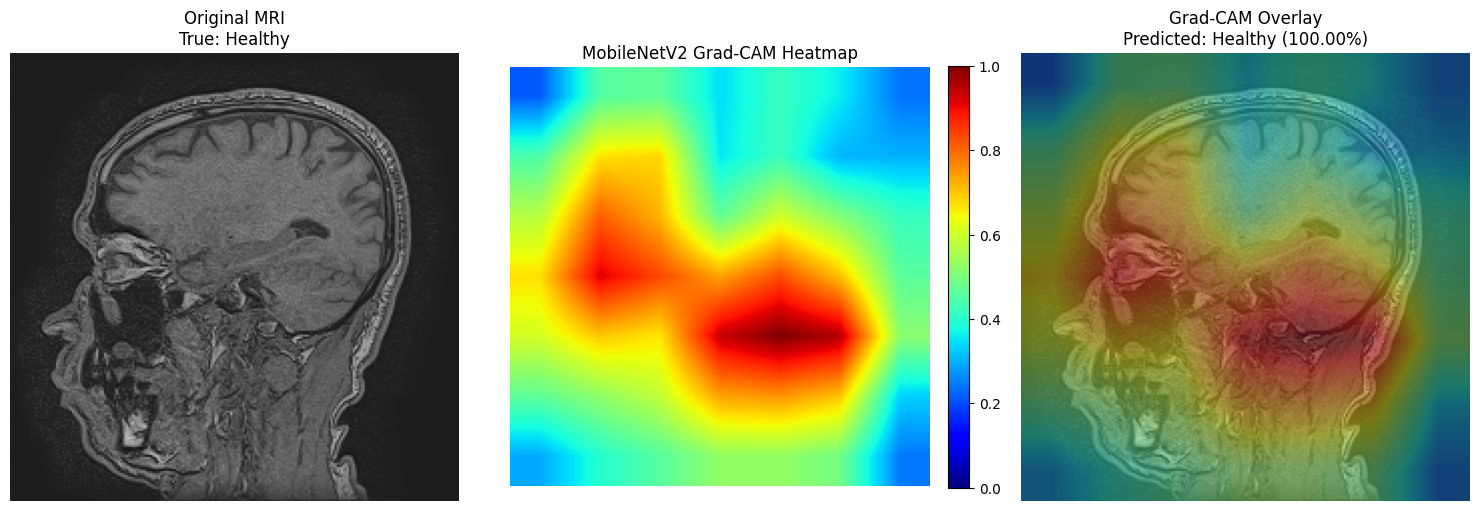

array([[[0.0682353 , 0.20705885, 0.4682353 ],
        [0.0682353 , 0.20705885, 0.4682353 ],
        [0.0682353 , 0.20705885, 0.4682353 ],
        ...,
        [0.0682353 , 0.2509804 , 0.4682353 ],
        [0.0682353 , 0.2509804 , 0.4682353 ],
        [0.0682353 , 0.2509804 , 0.4682353 ]],

       [[0.0682353 , 0.20705885, 0.4682353 ],
        [0.0682353 , 0.20705885, 0.4682353 ],
        [0.0682353 , 0.20705885, 0.4682353 ],
        ...,
        [0.0682353 , 0.2509804 , 0.4682353 ],
        [0.0682353 , 0.2509804 , 0.4682353 ],
        [0.0682353 , 0.2509804 , 0.4682353 ]],

       [[0.0682353 , 0.20705885, 0.4682353 ],
        [0.0682353 , 0.20705885, 0.4682353 ],
        [0.0682353 , 0.20705885, 0.4682353 ],
        ...,
        [0.0682353 , 0.2509804 , 0.4682353 ],
        [0.0682353 , 0.2509804 , 0.4682353 ],
        [0.0682353 , 0.2509804 , 0.4682353 ]],

       ...,

       [[0.0682353 , 0.33254904, 0.4682353 ],
        [0.0682353 , 0.33254904, 0.4682353 ],
        [0.0682353 , 0

In [108]:
# ==================================================
# PART 3 — SINGLE EXAMPLE GRAD-CAM
# ==================================================

print("\n--- Generating Single Image Grad-CAM ---")

# Define Grad-CAM parameters
LAST_CONV_LAYER_NAME = "Conv_1"  # As specified for MobileNetV2

# The classifier layer names for your model 'model_1'
# This is not directly used by make_mobilenet_gradcam, but kept for context
CLASSIFIER_LAYER_NAMES = [layer.name for layer in model_1.layers if isinstance(layer, (tf.keras.layers.Dense)) and layer.name != LAST_CONV_LAYER_NAME]

# Ensure the model_1 is loaded if not already in memory (e.g., if restarting kernel)
# model_1 = tf.keras.models.load_model(os.path.join(MODEL_DIR, "MobileNetV2_include_top_false_base_trainable_false_best.keras"))

# Select one healthy image from the test set for demonstration
single_image_df = test_df[test_df['label'] == '0'].sample(1, random_state=42)
single_image_path = single_image_df['image_path'].iloc[0]
single_image_true_label = single_image_df['label'].iloc[0]

print(f"Processing single image: {single_image_path}")

# Preprocess image
img_array = get_img_array(single_image_path, size=(IMG_SIZE, IMG_SIZE))

# Generate heatmap using the new function
heatmap, preds = make_mobilenet_gradcam(img_array, model_1, LAST_CONV_LAYER_NAME)

# Get prediction details
# If it's a binary sigmoid output, preds will be (prob_parkinson)
# Adjusting for sigmoid output for binary classification:
# Assuming 0: Healthy, 1: Parkinson
predicted_prob_parkinson = preds[0]
if predicted_prob_parkinson > 0.5:
    predicted_label = "Parkinson"
    predicted_confidence = predicted_prob_parkinson * 100
else:
    predicted_label = "Healthy"
    predicted_confidence = (1 - predicted_prob_parkinson) * 100

# Print requested information
print(f"Prediction: {predicted_label} (Confidence: {predicted_confidence[0]:.2f}%) | True Label: {'Healthy' if single_image_true_label == '0' else 'Parkinson'}")
print(f"Heatmap shape: {heatmap.shape}")
print(f"Minimum heatmap value: {np.min(heatmap):.4f}")
print(f"Maximum heatmap value: {np.max(heatmap):.4f}")

# Display and save Grad-CAM
single_gradcam_save_path = os.path.join(GRADCAM_DIR, "single_image_gradcam.png")
display_gradcam(
    single_image_path, heatmap,
    pred_label=predicted_label,
    pred_confidence=predicted_confidence[0],
    true_label=('Healthy' if single_image_true_label == '0' else 'Parkinson'),
    save_path=single_gradcam_save_path
)

In [111]:
from pathlib import Path
from PIL import Image
import numpy as np

# Dataset root
DATASET_ROOT = Path(
    "/content/drive/MyDrive/Colab Notebooks/"
    "Parkinson_mobilenet_dataset_unzipped_here/"
    "Parkinson_dataset"
)

# -------------------------------------------------
# Find all PNG images
# -------------------------------------------------
all_png_files = list(DATASET_ROOT.rglob("*.png"))

healthy_candidates = []
parkinson_candidates = []

for image_path in all_png_files:
    # Check only folders below DATASET_ROOT.
    relative_parts = [
        part.lower()
        for part in image_path.relative_to(DATASET_ROOT).parts
    ]

    if "healthy_dataset" in relative_parts:
        healthy_candidates.append(image_path)

    elif "parkinson_dataset" in relative_parts:
        parkinson_candidates.append(image_path)

print("Healthy images found:", len(healthy_candidates))
print("Parkinson images found:", len(parkinson_candidates))


# -------------------------------------------------
# Score images so mostly black slices are avoided
# -------------------------------------------------
def representative_image_score(image_path):
    try:
        image = Image.open(image_path).convert("L")
        image = image.resize((224, 224))

        image_array = np.asarray(
            image,
            dtype=np.float32
        ) / 255.0

        # Foreground pixels
        foreground_ratio = np.mean(image_array > 0.08)

        # Image variation
        contrast = np.std(image_array)

        # Reject nearly empty images
        if foreground_ratio < 0.15:
            return -1.0

        return float(
            foreground_ratio * contrast
        )

    except Exception as error:
        print("Could not inspect:", image_path)
        print(error)
        return -1.0


healthy_candidates = sorted(
    healthy_candidates,
    key=representative_image_score,
    reverse=True
)

parkinson_candidates = sorted(
    parkinson_candidates,
    key=representative_image_score,
    reverse=True
)

if len(healthy_candidates) < 2:
    raise ValueError(
        "Fewer than two Healthy images were found."
    )

if len(parkinson_candidates) < 2:
    raise ValueError(
        "Fewer than two Parkinson images were found."
    )


# -------------------------------------------------
# Create the missing variables
# -------------------------------------------------
selected_image_paths = [
    str(healthy_candidates[0]),
    str(healthy_candidates[1]),
    str(parkinson_candidates[0]),
    str(parkinson_candidates[1])
]

selected_true_labels = [
    "Healthy",
    "Healthy",
    "Parkinson",
    "Parkinson"
]

print("\nSelected Grad-CAM images:")

for number, (path, label) in enumerate(
    zip(selected_image_paths, selected_true_labels),
    start=1
):
    print(f"{number}. {label}")
    print(path)

Healthy images found: 5560
Parkinson images found: 5560

Selected Grad-CAM images:
1. Healthy
/content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_dataset_unzipped_here/Parkinson_dataset/healthy_dataset/control_png/PPMI_149005_MR_3D_T1-weighted_br_raw_20220804200224889_296_S1152393_I1611833.png
2. Healthy
/content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_dataset_unzipped_here/Parkinson_dataset/healthy_dataset/control_png/PPMI_149006_MR_3D_T1-weighted_br_raw_20220828210449939_266_S1156465_I1617083.png
3. Parkinson
/content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_dataset_unzipped_here/Parkinson_dataset/parkinson_dataset/pd_png/PPMI_101799_MR_SAG_3D_T1_FSPGR__br_raw_20210924184255498_110_S1066403_I1496495.png
4. Parkinson
/content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_dataset_unzipped_here/Parkinson_dataset/parkinson_dataset/pd_png/PPMI_101799_MR_SAG_3D_T1_FSPGR__br_raw_20210924183838808_95_S1066403_I1496495.png



--- Generating Multiple Image Grad-CAM Examples ---

Processing image 1/4:
PPMI_149005_MR_3D_T1-weighted_br_raw_20220804200224889_296_S1152393_I1611833.png
Backbone: mobilenetv2_1.00_224
Last convolution layer: Conv_1
Model input shape: (1, 224, 224, 3)
Convolution output shape: (1, 7, 7, 1280)
Prediction: [[0.0001367]]
Gradient minimum: -0.045562148094177246
Gradient maximum: 0.05109333619475365
Gradient norm: 1.269048810005188
Heatmap minimum: 0.0
Heatmap maximum: 1.0
True label: Healthy
Predicted label: Healthy
Parkinson probability: 0.00013670
Confidence: 99.99%

>>> FIXED display_gradcam VERSION 4 IS RUNNING <<<
Original image shape: (224, 224, 3)
RGBA heatmap shape: (224, 224, 4)
RGB heatmap shape: (224, 224, 3)
Overlay shape: (224, 224, 3)
Saved corrected Grad-CAM:
/content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/grad_cam_outputs/mobilenet_gradcam_healthy_1.png


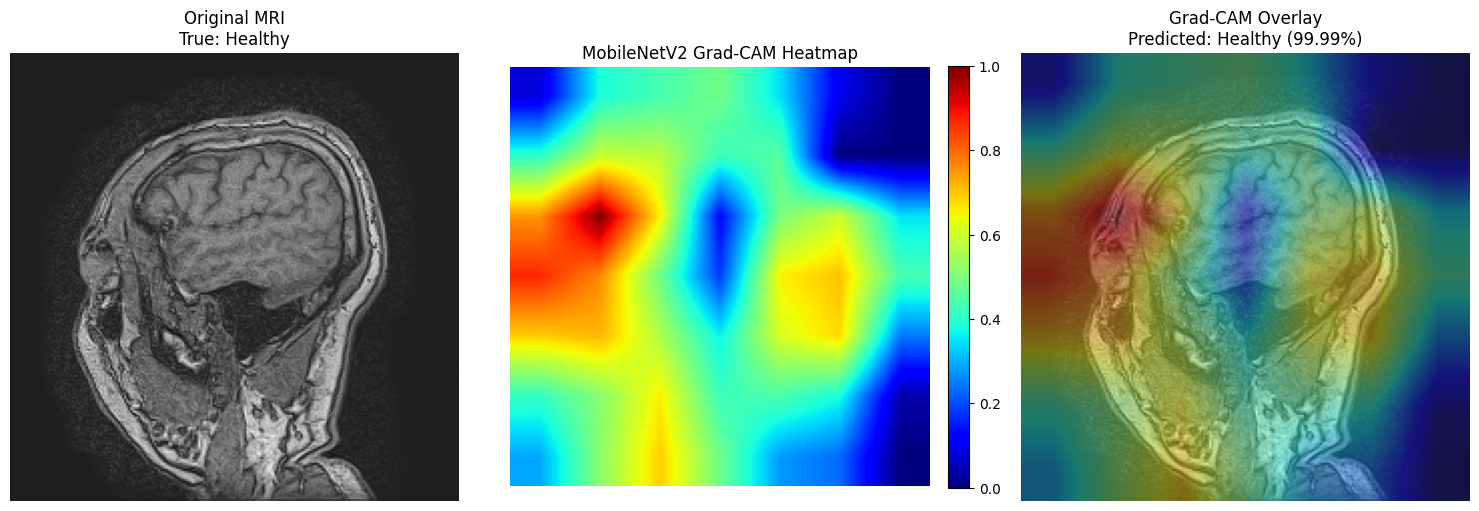


Processing image 2/4:
PPMI_149006_MR_3D_T1-weighted_br_raw_20220828210449939_266_S1156465_I1617083.png
Backbone: mobilenetv2_1.00_224
Last convolution layer: Conv_1
Model input shape: (1, 224, 224, 3)
Convolution output shape: (1, 7, 7, 1280)
Prediction: [[1.20589975e-05]]
Gradient minimum: -0.0441814586520195
Gradient maximum: 0.0526844747364521
Gradient norm: 1.261332392692566
Heatmap minimum: 0.0
Heatmap maximum: 1.0
True label: Healthy
Predicted label: Healthy
Parkinson probability: 0.00001206
Confidence: 100.00%

>>> FIXED display_gradcam VERSION 4 IS RUNNING <<<
Original image shape: (224, 224, 3)
RGBA heatmap shape: (224, 224, 4)
RGB heatmap shape: (224, 224, 3)
Overlay shape: (224, 224, 3)
Saved corrected Grad-CAM:
/content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/grad_cam_outputs/mobilenet_gradcam_healthy_2.png


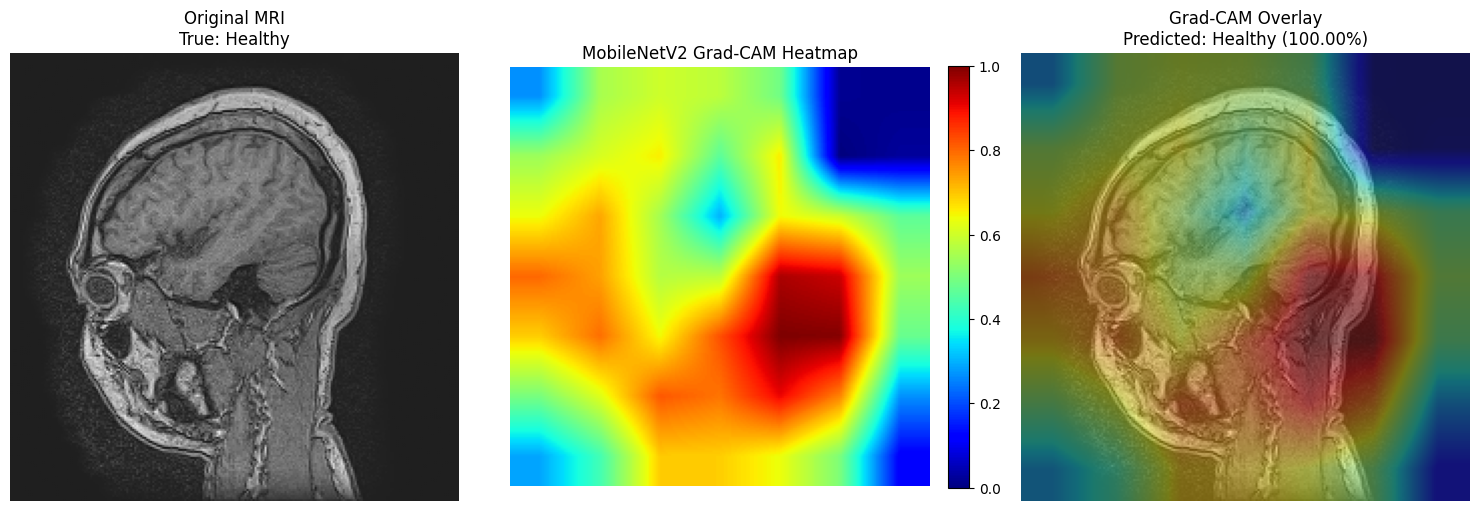


Processing image 3/4:
PPMI_101799_MR_SAG_3D_T1_FSPGR__br_raw_20210924184255498_110_S1066403_I1496495.png
Backbone: mobilenetv2_1.00_224
Last convolution layer: Conv_1
Model input shape: (1, 224, 224, 3)
Convolution output shape: (1, 7, 7, 1280)
Prediction: [[0.99734384]]
Gradient minimum: -0.04415643587708473
Gradient maximum: 0.04602132365107536
Gradient norm: 1.2708392143249512
Heatmap minimum: 0.0
Heatmap maximum: 1.0
True label: Parkinson
Predicted label: Parkinson
Parkinson probability: 0.99734384
Confidence: 99.73%

>>> FIXED display_gradcam VERSION 4 IS RUNNING <<<
Original image shape: (224, 224, 3)
RGBA heatmap shape: (224, 224, 4)
RGB heatmap shape: (224, 224, 3)
Overlay shape: (224, 224, 3)
Saved corrected Grad-CAM:
/content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/grad_cam_outputs/mobilenet_gradcam_parkinson_3.png


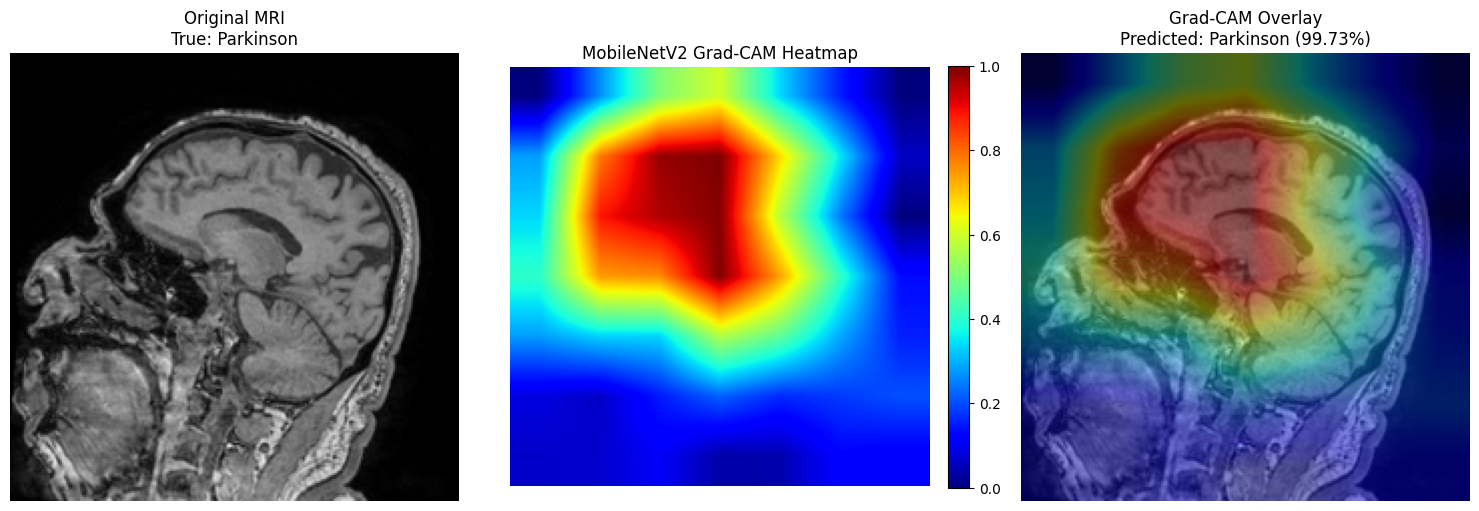


Processing image 4/4:
PPMI_101799_MR_SAG_3D_T1_FSPGR__br_raw_20210924183838808_95_S1066403_I1496495.png
Backbone: mobilenetv2_1.00_224
Last convolution layer: Conv_1
Model input shape: (1, 224, 224, 3)
Convolution output shape: (1, 7, 7, 1280)
Prediction: [[0.98840755]]
Gradient minimum: -0.037956513464450836
Gradient maximum: 0.04603278636932373
Gradient norm: 1.177931308746338
Heatmap minimum: 0.0
Heatmap maximum: 1.0
True label: Parkinson
Predicted label: Parkinson
Parkinson probability: 0.98840755
Confidence: 98.84%

>>> FIXED display_gradcam VERSION 4 IS RUNNING <<<
Original image shape: (224, 224, 3)
RGBA heatmap shape: (224, 224, 4)
RGB heatmap shape: (224, 224, 3)
Overlay shape: (224, 224, 3)
Saved corrected Grad-CAM:
/content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/grad_cam_outputs/mobilenet_gradcam_parkinson_4.png


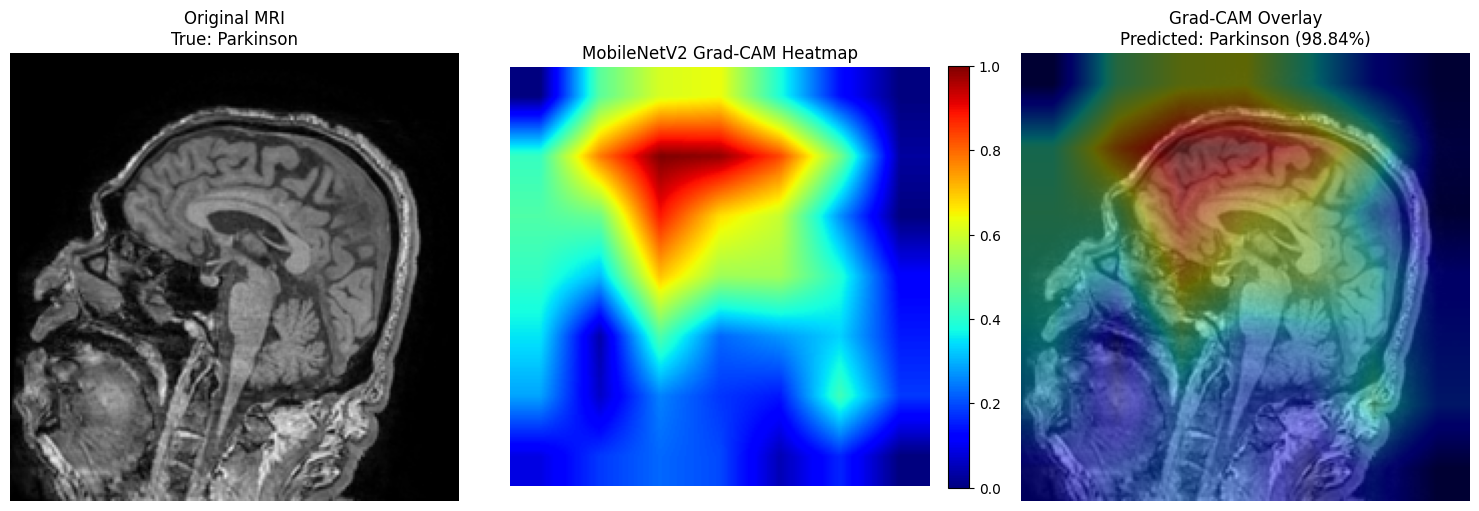

In [112]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras


print("\n--- Generating Multiple Image Grad-CAM Examples ---")

# selected_image_paths should contain the image paths you selected.
# selected_true_labels should contain Healthy/Parkinson for those paths.

for display_number, (img_path, true_label) in enumerate(
    zip(selected_image_paths, selected_true_labels),
    start=1
):
    print(
        f"\nProcessing image {display_number}/"
        f"{len(selected_image_paths)}:"
    )
    print(os.path.basename(img_path))

    # ------------------------------------------------
    # Load image using the SAME preprocessing as before
    # ------------------------------------------------
    img = keras.utils.load_img(
        img_path,
        target_size=(224, 224),
        color_mode="rgb"
    )

    img_array = keras.utils.img_to_array(img)

    # Use the exact preprocessing used during training.
    # Keep this line only if your original pipeline used
    # MobileNetV2 preprocess_input.
    img_array = keras.applications.mobilenet_v2.preprocess_input(
        img_array
    )

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    # ------------------------------------------------
    # Correct nested MobileNetV2 Grad-CAM
    # ------------------------------------------------
    heatmap, preds = make_mobilenet_gradcam(
        img_array=img_array,
        model=model_1,
        last_conv_layer_name="Conv_1"
    )

    # ------------------------------------------------
    # Prediction information
    # ------------------------------------------------
    parkinson_probability = float(
        np.asarray(preds).reshape(-1)[0]
    )

    if parkinson_probability >= 0.5:
        predicted_label = "Parkinson"
        confidence = parkinson_probability * 100.0
    else:
        predicted_label = "Healthy"
        confidence = (
            1.0 - parkinson_probability
        ) * 100.0

    print(
        f"True label: {true_label}"
    )
    print(
        f"Predicted label: {predicted_label}"
    )
    print(
        f"Parkinson probability: "
        f"{parkinson_probability:.8f}"
    )
    print(
        f"Confidence: {confidence:.2f}%"
    )

    # ------------------------------------------------
    # Save with a unique filename
    # ------------------------------------------------
    safe_true_label = str(
        true_label
    ).lower().replace(" ", "_")

    save_path = os.path.join(
        GRADCAM_DIR,
        (
            f"mobilenet_gradcam_"
            f"{safe_true_label}_"
            f"{display_number}.png"
        )
    )

    # Call your corrected RGB display function.
    # Do not call an older display function.
    display_gradcam(
        img_path=img_path,
        heatmap=heatmap,
        alpha=0.40,
        pred_label=predicted_label,
        pred_confidence=confidence,
        true_label=true_label,
        save_path=save_path
    )

### Model Parameters and Architecture for MobileNetV2 (`model_1`)

This section details the architecture of `model_1`, including its summary, parameter counts, and a visual representation of its structure. These artifacts are crucial for understanding the model's complexity and are saved for the IEEE journal paper.

In [113]:
# ==================================================
# PART 6 — MODEL PARAMETERS AND ARCHITECTURE
# ==================================================

print("\n--- Model Summary and Parameters for Model 1 ---")

# 1. Print model.summary()
model_1.summary()

# 2. Calculate Parameters
total_params = model_1.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in model_1.trainable_weights])
non_trainable_params = sum([tf.keras.backend.count_params(w) for w in model_1.non_trainable_weights])

# 5. Print the parameter counts on the screen.
print(f"\nTotal Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Non-Trainable Parameters: {non_trainable_params:,}")

# 3. Save the complete model summary into a text file
summary_file_path = os.path.join(ROC_DATA_DIR, "mobilenet_model_summary.txt")
with open(summary_file_path, 'w') as f:
    model_1.summary(print_fn=lambda x: f.write(x + '\n'))
print(f"Complete model summary saved to: {summary_file_path}")

# 4. Save the parameter counts into a CSV file
param_data = {
    "Model Name": [model_name_1],
    "Total Parameters": [total_params],
    "Trainable Parameters": [trainable_params],
    "Non-Trainable Parameters": [non_trainable_params]
}
param_df = pd.DataFrame(param_data)
parameters_csv_path = os.path.join(ROC_DATA_DIR, "mobilenet_parameters.csv")
param_df.to_csv(parameters_csv_path, index=False)
print(f"Parameter counts saved to: {parameters_csv_path}")


--- Model Summary and Parameters for Model 1 ---


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,343,941 (12.76 MB)

 Trainable params: 361,729 (1.38 MB)

 Non-trainable params: 2,258,752 (8.62 MB)

 Optimizer params: 723,460 (2.76 MB)


Total Parameters: 2,620,481
Trainable Parameters: 361,729
Non-Trainable Parameters: 2,258,752


Complete model summary saved to: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/ROC_DATA/mobilenet_model_summary.txt
Parameter counts saved to: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/ROC_DATA/mobilenet_parameters.csv


In [114]:
print("\n--- Saving Model Architecture Diagram ---")

# 6. Save the model architecture diagram as a PNG
architecture_png_path = os.path.join(ROC_DATA_DIR, "mobilenet_architecture.png")

try:
    tf.keras.utils.plot_model(
        model_1,
        to_file=architecture_png_path,
        show_shapes=True,
        show_dtype=False,
        expand_nested=True,
        dpi=300
    )
    print(f"Model architecture diagram saved to: {architecture_png_path}")
except ImportError:
    print("Graphviz is not installed. Skipping model architecture diagram generation.")
    print("To enable this feature, please install Graphviz: pip install pydot graphviz")
except Exception as e:
    print(f"An error occurred while trying to save the model architecture diagram: {e}")


--- Saving Model Architecture Diagram ---
Model architecture diagram saved to: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/ROC_DATA/mobilenet_architecture.png


Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,481 (10.00 MB)

 Trainable params: 2,585,601 (9.86 MB)

 Non-trainable params: 34,880 (136.25 KB)

Epoch 1/35
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.6337 - auc: 0.6905 - loss: 0.7156
Epoch 1: val_auc improved from None to 0.77879, saving model to /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/models/MobileNetV2_include_top_false_base_trainable_true_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/models/MobileNetV2_include_top_false_base_trainable_true_best.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 207s 607ms/step - accuracy: 0.6844 - auc: 0.7602 - loss: 0.6278 - val_accuracy: 0.6739 - val_auc: 0.7788 - val_loss: 0.5811 - learning_rate: 1.0000e-04
Epoch 2/35
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.7704 - auc: 0.8605 - loss: 0.4712
Epoch 2: val_auc improved from 0.77879 to 0.81687, saving model to /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/models/MobileNetV2_include_top_false_base_trainable_true_best.keras

Epoch 2: finished s

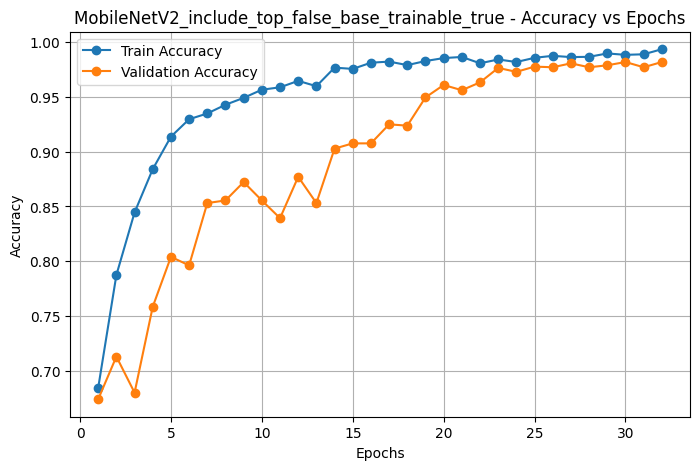

Saved: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/graphs/MobileNetV2_include_top_false_base_trainable_true_accuracy_vs_epochs.png


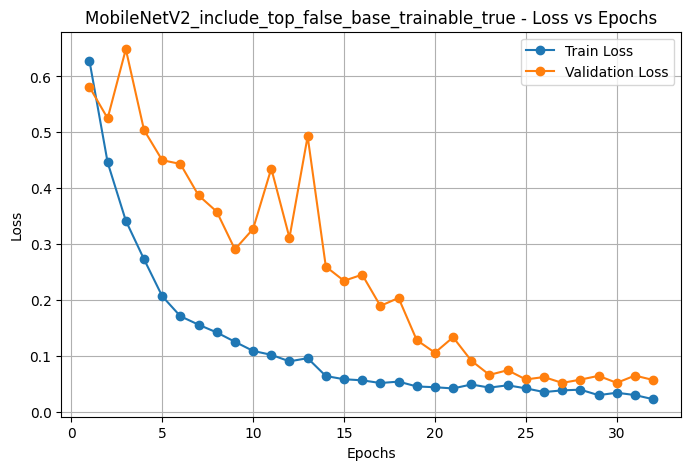

Saved: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/graphs/MobileNetV2_include_top_false_base_trainable_true_loss_vs_epochs.png


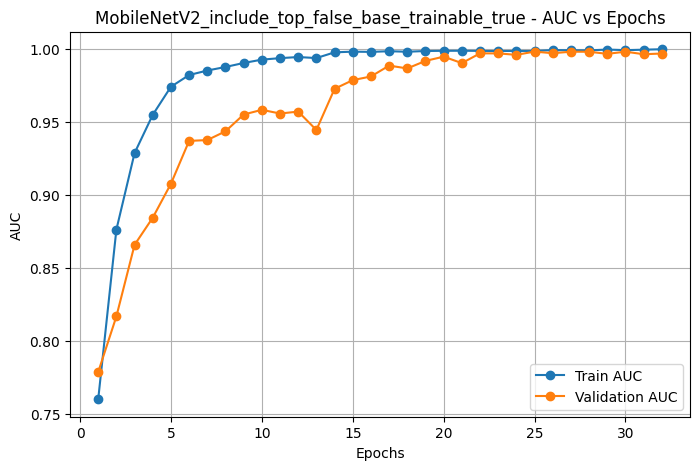

Saved: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/graphs/MobileNetV2_include_top_false_base_trainable_true_auc_vs_epochs.png
53/53 ━━━━━━━━━━━━━━━━━━━━ 14s 176ms/step

MobileNetV2_include_top_false_base_trainable_true
Accuracy: 0.9790167865707434
F1 Score: 0.9790794979079498
ROC AUC: 0.9978520780497904

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.98      0.98      0.98       834
   Parkinson       0.98      0.98      0.98       834

    accuracy                           0.98      1668
   macro avg       0.98      0.98      0.98      1668
weighted avg       0.98      0.98      0.98      1668


Confusion Matrix:
[[814  20]
 [ 15 819]]
Prediction data (y_true, y_pred, y_prob) saved: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/confusion_matrices/MobileNetV2_include_top_false_base_trainable_true_predictions.npz
Report saved: /content/drive/MyDrive/Colab Notebooks/Parkinson_

<Figure size 600x600 with 0 Axes>

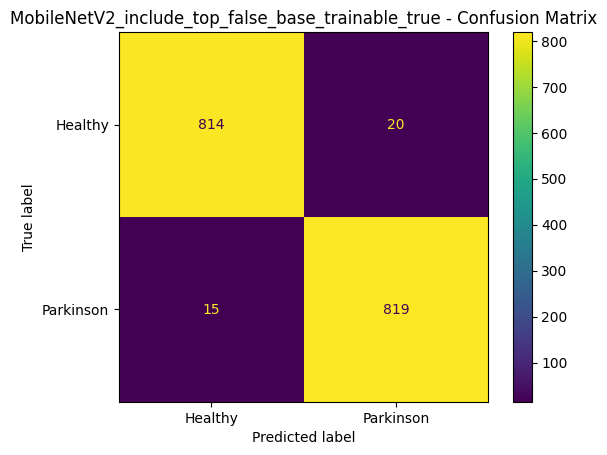

Confusion matrix image saved: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/confusion_matrices/MobileNetV2_include_top_false_base_trainable_true_confusion_matrix.png


In [115]:
# ================================
# MODEL 2: BASE TRAINABLE TRUE
# ================================

model_name_2 = "MobileNetV2_include_top_false_base_trainable_true"

model_2 = build_mobilenetv2_model(base_trainable=True)

model_2.summary()

callbacks_2 = [
    EarlyStopping(
        monitor="val_auc",
        patience=7,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, f"{model_name_2}_best.keras"),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    CSVLogger(
        filename=os.path.join(HISTORY_DIR, f"{model_name_2}_training_log.csv")
    )
]

history_2 = model_2.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks_2
)

# Save final model
model_2_final_path = os.path.join(MODEL_DIR, f"{model_name_2}_final.keras")
model_2.save(model_2_final_path)
print("Final model saved:", model_2_final_path)

# Save history JSON
history_2_path = os.path.join(HISTORY_DIR, f"{model_name_2}_history.json")
with open(history_2_path, "w") as f:
    json.dump(history_2.history, f)

print("History saved:", history_2_path)

# Plot graphs
plot_training_history(history_2, model_name_2)

# Evaluate model
results_2 = evaluate_model(model_2, test_gen, model_name_2)

In [116]:
# ================================
# COMPARE BOTH MODELS
# ================================

comparison_df = pd.DataFrame([
    {
        "Model": results_1["model_name"],
        "include_top": False,
        "base_trainable": False,
        "Accuracy": results_1["accuracy"],
        "F1 Score": results_1["f1_score"],
        "ROC AUC": results_1["roc_auc"]
    },
    {
        "Model": results_2["model_name"],
        "include_top": False,
        "base_trainable": True,
        "Accuracy": results_2["accuracy"],
        "F1 Score": results_2["f1_score"],
        "ROC AUC": results_2["roc_auc"]
    }
])

comparison_path = os.path.join(REPORT_DIR, "mobilenetv2_model_comparison.csv")
comparison_df.to_csv(comparison_path, index=False)

print("Comparison saved:", comparison_path)
comparison_df

Comparison saved: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/reports/mobilenetv2_model_comparison.csv


,Model,include_top,base_trainable,Accuracy,F1 Score,ROC AUC
0,MobileNetV2_include_top_false_base_trainable_f...,False,False,0.889089,0.887401,0.963071
1,MobileNetV2_include_top_false_base_trainable_true,False,True,0.979017,0.979079,0.997852


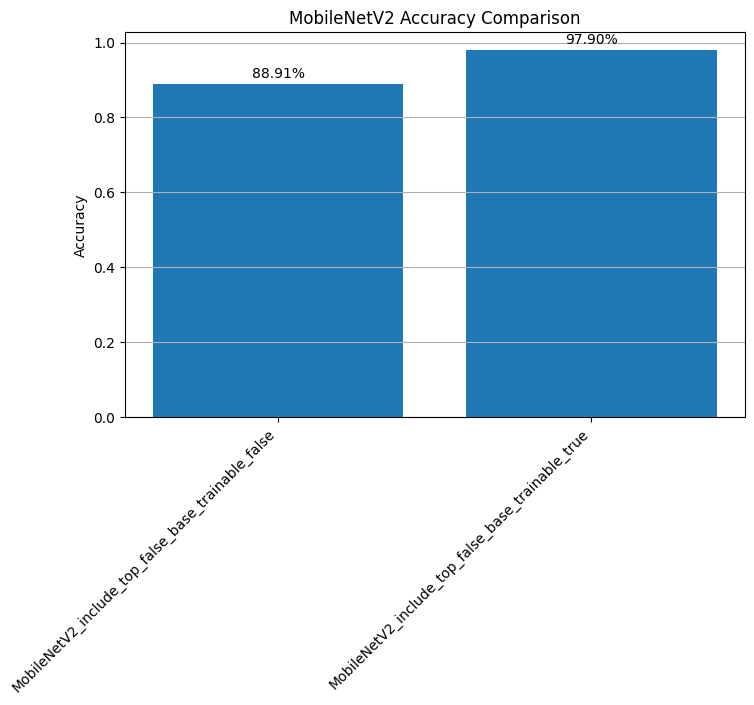

Saved: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/graphs/mobilenetv2_accuracy_comparison.png


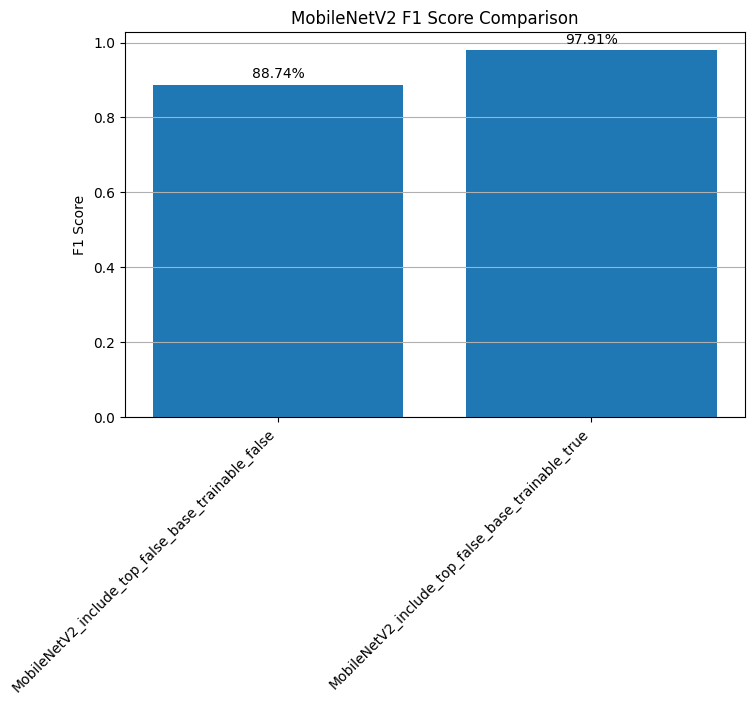

Saved: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/graphs/mobilenetv2_f1_comparison.png


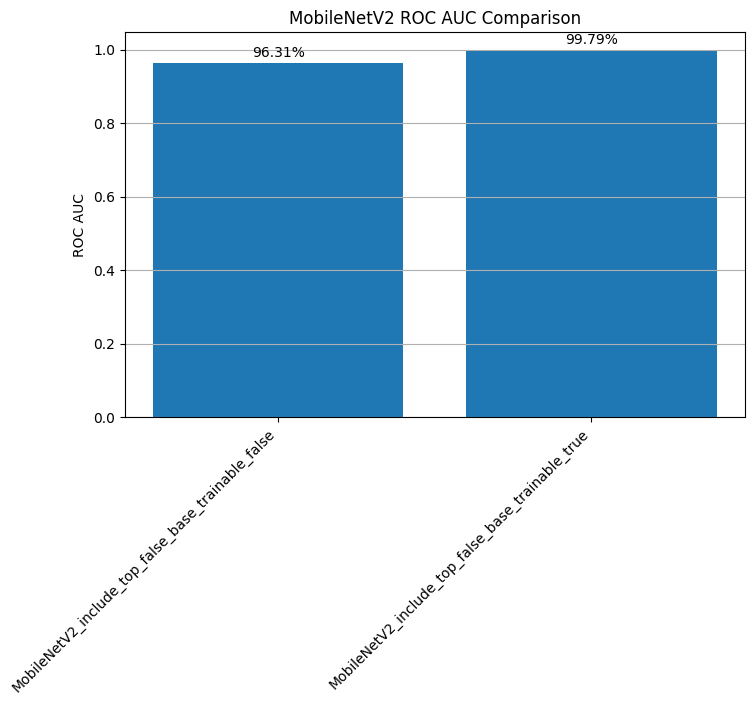

Saved: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/graphs/mobilenetv2_auc_comparison.png


In [117]:
# ================================
# COMPARISON GRAPHS
# ================================

# Accuracy comparison
plt.figure(figsize=(8, 5))
bar_container_acc = plt.bar(comparison_df["Model"], comparison_df["Accuracy"])
plt.title("MobileNetV2 Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
for bar in bar_container_acc:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2%}', ha='center', va='bottom') # Adjusted for percentage and position
acc_compare_path = os.path.join(GRAPH_DIR, "mobilenetv2_accuracy_comparison.png")
plt.savefig(acc_compare_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", acc_compare_path)

# F1 comparison
plt.figure(figsize=(8, 5))
bar_container_f1 = plt.bar(comparison_df["Model"], comparison_df["F1 Score"])
plt.title("MobileNetV2 F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
for bar in bar_container_f1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2%}', ha='center', va='bottom') # Adjusted for percentage and position
f1_compare_path = os.path.join(GRAPH_DIR, "mobilenetv2_f1_comparison.png")
plt.savefig(f1_compare_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", f1_compare_path)

# ROC AUC comparison
plt.figure(figsize=(8, 5))
bar_container_auc = plt.bar(comparison_df["Model"], comparison_df["ROC AUC"])
plt.title("MobileNetV2 ROC AUC Comparison")
plt.ylabel("ROC AUC")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
for bar in bar_container_auc:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2%}', ha='center', va='bottom') # Adjusted for percentage and position
auc_compare_path = os.path.join(GRAPH_DIR, "mobilenetv2_auc_comparison.png")
plt.savefig(auc_compare_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", auc_compare_path)


In [118]:
# ================================
# CHECK SAVED OUTPUTS
# ================================

print("Models saved in:", MODEL_DIR)
print(os.listdir(MODEL_DIR))

print("\nGraphs saved in:", GRAPH_DIR)
print(os.listdir(GRAPH_DIR))

print("\nConfusion matrices saved in:", CM_DIR)
print(os.listdir(CM_DIR))

print("\nReports saved in:", REPORT_DIR)
print(os.listdir(REPORT_DIR))

print("\nHistory files saved in:", HISTORY_DIR)
print(os.listdir(HISTORY_DIR))

Models saved in: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/models
['MobileNetV2_include_top_false_base_trainable_false_best.keras', 'MobileNetV2_include_top_false_base_trainable_false_final.keras', 'MobileNetV2_include_top_false_base_trainable_true_best.keras', 'MobileNetV2_include_top_false_base_trainable_true_final.keras']

Graphs saved in: /content/drive/MyDrive/Colab Notebooks/Parkinson_mobilenet_data_Saved_here/graphs
['MobileNetV2_include_top_false_base_trainable_false_accuracy_vs_epochs.png', 'MobileNetV2_include_top_false_base_trainable_false_loss_vs_epochs.png', 'MobileNetV2_include_top_false_base_trainable_false_auc_vs_epochs.png', 'MobileNetV2_include_top_false_base_trainable_true_accuracy_vs_epochs.png', 'MobileNetV2_include_top_false_base_trainable_true_loss_vs_epochs.png', 'MobileNetV2_include_top_false_base_trainable_true_auc_vs_epochs.png', 'mobilenetv2_accuracy_comparison.png', 'mobilenetv2_f1_comparison.png', 'mobilenetv2_auc_compariso